# 07 — Physical Dimer Regime Maps

This notebook identifies the physical regimes in which the conventional
impulsive rotating-wave approximation is quantitatively accurate and
separates the mechanisms responsible for its breakdown.

We compare four levels of theory:

\[
\begin{aligned}
A &: \text{finite pulse + full interaction }V,\\
B &: \text{finite pulse + molecular RWA},\\
C &: \text{short-pulse RWA},\\
D &: \text{impulsive RWA}.
\end{aligned}
\]

The corresponding differences isolate distinct approximations:

\[
A-B
\]

measures the molecular-RWA error,

\[
B-C
\]

measures molecular evolution during the finite pulse,

\[
C-D
\]

measures finite spectral-bandwidth effects, and

\[
A-D
\]

measures the total error of the conventional impulsive-RWA description.

The final objective is a regime map as a function of molecular energy
scales and pulse duration.

In [1]:
from pathlib import Path
import sys
import platform

import numpy as np
import scipy
import matplotlib.pyplot as plt

import pulsus


print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("PULSUS:", pulsus.__file__)

Python: 3.11.4
Platform: macOS-26.6-arm64-arm-64bit
NumPy: 2.4.6
SciPy: 1.17.1
PULSUS: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/src/pulsus/__init__.py


## 1. Physical units and baseline dimer

We work in electron-volts and femtoseconds, with

\[
\hbar = 0.6582119569\ {\rm eV\,fs}.
\]

The baseline dimer is centered near an optical transition energy of
\(2\,{\rm eV}\), with moderate site detuning and electronic coupling.
This reference point will be used to verify the A/B/C/D hierarchy
before scanning parameter space.

In [2]:
# Physical constants
HBAR_EV_FS = 0.6582119569  # eV fs

# ------------------------------------------------------------
# Baseline electronic dimer
# ------------------------------------------------------------

E_center = 2.00       # eV
detuning = 0.040      # eV = 40 meV
J = 0.040             # eV = 40 meV

E_a = E_center - detuning / 2
E_b = E_center + detuning / 2

# Exciton splitting
DeltaE_ex = np.sqrt(
    (E_a - E_b)**2
    + 4 * J**2
)

# ------------------------------------------------------------
# Baseline pulse
# ------------------------------------------------------------

intensity_fwhm = 20.0  # fs

# For field amplitude exp[-t^2/(2 sigma^2)],
# intensity FWHM = 2 sqrt(ln 2) sigma
sigma = (
    intensity_fwhm
    / (2 * np.sqrt(np.log(2)))
)

# Waiting time chosen safely in separated-pulse regime
T = 6.0 * sigma

# Optical carrier angular frequency
omega_L = E_center / HBAR_EV_FS

print(f"E_a = {E_a:.4f} eV")
print(f"E_b = {E_b:.4f} eV")
print(f"J = {J:.4f} eV")
print(f"Exciton splitting = {1000 * DeltaE_ex:.2f} meV")
print()
print(f"Intensity FWHM = {intensity_fwhm:.2f} fs")
print(f"sigma = {sigma:.4f} fs")
print(f"T = {T:.4f} fs = {T/sigma:.1f} sigma")
print(f"omega_L = {omega_L:.4f} fs^-1")

E_a = 1.9800 eV
E_b = 2.0200 eV
J = 0.0400 eV
Exciton splitting = 89.44 meV

Intensity FWHM = 20.00 fs
sigma = 12.0112 fs
T = 72.0673 fs = 6.0 sigma
omega_L = 3.0385 fs^-1


In [3]:
# ------------------------------------------------------------
# Dimensionless in-pulse dynamics parameter
# ------------------------------------------------------------

chi_dyn = (
    sigma * DeltaE_ex / HBAR_EV_FS
)

tau_ex = (
    HBAR_EV_FS / DeltaE_ex
)

print(f"Excitonic timescale hbar/DeltaE_ex = {tau_ex:.4f} fs")
print(f"sigma / tau_ex = {sigma / tau_ex:.4f}")
print(f"chi_dyn = {chi_dyn:.4f}")

Excitonic timescale hbar/DeltaE_ex = 7.3590 fs
sigma / tau_ex = 1.6322
chi_dyn = 1.6322


The dimensionless parameter

\[
\chi_{\rm dyn}
=
\frac{\sigma\Delta E_{\rm ex}}{\hbar}
\]

measures the characteristic molecular phase accumulated during one
Gaussian pulse width.

For the baseline point,

\[
\chi_{\rm dyn}\approx1.63,
\]

so molecular evolution during the pulse is not expected to be
negligible. This point therefore provides a useful initial test of the
difference between Models B and C.

## 2. Physical dimer model

The existing PULSUS dimer builder is reused in physical units.

Because the model Hamiltonian is written as

\[
H_S
=
\hbar\omega_a n_a
+
\hbar\omega_b n_b
+
\hbar J_\omega
\left(
\sigma_a^+\sigma_b^-
+
\sigma_a^-\sigma_b^+
\right),
\]

energies specified in electron-volts are converted to angular
frequencies through

\[
\omega = E/\hbar.
\]

The baseline dissipation rate is fixed at

\[
\gamma_a=\gamma_b=0.02\ {\rm fs}^{-1},
\]

and thermal optical excitation is neglected,
\(\bar n_a=\bar n_b=0\).

In [4]:
from dimer_model import build_dimer

# ------------------------------------------------------------
# Convert physical energies to angular frequencies
# ------------------------------------------------------------

omega_a = E_a / HBAR_EV_FS
omega_b = E_b / HBAR_EV_FS
J_omega = J / HBAR_EV_FS

# Fixed open-system parameters
gamma_a = 0.020  # fs^-1
gamma_b = 0.020  # fs^-1

nbar_a = 0.0
nbar_b = 0.0

model = build_dimer(
    omega_a=omega_a,
    omega_b=omega_b,
    J=J_omega,
    gamma_a=gamma_a,
    gamma_b=gamma_b,
    nbar_a=nbar_a,
    nbar_b=nbar_b,
    mu_a=1.0,
    mu_b=1.0,
    hbar=HBAR_EV_FS,
)

print(f"omega_a = {omega_a:.6f} fs^-1")
print(f"omega_b = {omega_b:.6f} fs^-1")
print(f"J_omega = {J_omega:.6f} fs^-1")
print()

print("Hamiltonian eigenvalues (eV):")
print(np.linalg.eigvalsh(model["H_S"]))

print()
print(f"population lifetime 1/gamma = {1/gamma_a:.2f} fs")

omega_a = 3.008150 fs^-1
omega_b = 3.068920 fs^-1
J_omega = 0.060771 fs^-1

Hamiltonian eigenvalues (eV):
[0.         1.95527864 2.04472136 4.        ]

population lifetime 1/gamma = 50.00 fs


In [5]:
# ------------------------------------------------------------
# PULSUS spectroscopy system
# ------------------------------------------------------------

collapse_ops = [
    model["L_a_down"],
    model["L_a_up"],
    model["L_b_down"],
    model["L_b_up"],
]

mu_plus = (
    model["sigma_a_plus"]
    + model["sigma_b_plus"]
)

mu_minus = (
    model["sigma_a_minus"]
    + model["sigma_b_minus"]
)

system = pulsus.SpectroscopySystem(
    H=model["H_S"],
    dipole=model["mu"],
    collapse_ops=collapse_ops,
    rho0=model["rho0"],
    hbar=HBAR_EV_FS,
    dipole_plus=mu_plus,
    dipole_minus=mu_minus,
)

print("Hilbert-space dimension:", system.d)
print("Liouville-space dimension:", system.L.shape[0])

print()
print("V available:", system.V is not None)
print("V_plus available:", system.V_plus is not None)
print("V_minus available:", system.V_minus is not None)

print()
print("rho0 trace:", np.trace(system.rho0))
print(
    "||L rho0|| =",
    np.linalg.norm(
        system.L @ pulsus.vec(system.rho0)
    )
)

Hilbert-space dimension: 4
Liouville-space dimension: 16

V available: True
V_plus available: True
V_minus available: True

rho0 trace: (1+0j)
||L rho0|| = 0.0


## 3. Baseline pulse and spectral grid

All three pulses are taken to be identical Gaussian pulses centered at

\[
E_L = 2.00\ {\rm eV}.
\]

The field amplitude is chosen such that the Gaussian spectral prefactor
at zero detuning is unity,

\[
\frac{E_0}{2}\sqrt{2\pi}\sigma = 1.
\]

This places the finite-pulse and impulsive calculations on a common
natural amplitude scale.

The spectral axes are evaluated in angular frequency internally and
converted to electron-volts for plotting.

In [6]:
# ------------------------------------------------------------
# Gaussian pulse
# ------------------------------------------------------------

E0_pulse = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma
    )
)

pulse = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma,
    E0=E0_pulse,
)

# Tiny numerical convergence parameter.
# Physical linewidths are already contained in system.L.
eta = 1.0e-10  # fs^-1


# ------------------------------------------------------------
# Frequency grid
# ------------------------------------------------------------

E_min = 1.75  # eV
E_max = 2.25  # eV
n_omega = 161

E1_grid = np.linspace(
    E_min,
    E_max,
    n_omega,
)

E3_grid = np.linspace(
    E_min,
    E_max,
    n_omega,
)

omega1_grid = E1_grid / HBAR_EV_FS
omega3_grid = E3_grid / HBAR_EV_FS


print(f"E0 pulse = {E0_pulse:.8f} fs^-1")
print(
    "Gaussian spectral prefactor C =",
    pulsus.gaussian_prefactor(
        sigma=sigma,
        E0=E0_pulse,
    ),
)

print()
print(
    f"Grid: {n_omega} x {n_omega}"
)
print(
    f"Energy range: {E_min:.2f} to {E_max:.2f} eV"
)
print(
    f"Energy spacing: "
    f"{1000*(E1_grid[1]-E1_grid[0]):.3f} meV"
)

E0 pulse = 0.06642825 fs^-1
Gaussian spectral prefactor C = (1+0j)

Grid: 161 x 161
Energy range: 1.75 to 2.25 eV
Energy spacing: 3.125 meV


In [7]:
# ------------------------------------------------------------
# Baseline A/B/C/D comparison: nonrephasing branch
# ------------------------------------------------------------

pathway = "NR"

# A: finite pulse + full interaction V
S_A_NR = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway=pathway,
)

# B: finite pulse + molecular RWA
S_B_NR = pulsus.finite_pulse_rwa_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway=pathway,
)

# C: short-pulse RWA
S_C_NR = pulsus.short_pulse_rwa_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway=pathway,
)

# D: impulsive RWA
S_D_NR = pulsus.impulsive_rwa_spectrum(
    system=system,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway=pathway,
)


print("Shapes:")
print("A:", S_A_NR.shape)
print("B:", S_B_NR.shape)
print("C:", S_C_NR.shape)
print("D:", S_D_NR.shape)

print()
print("All finite:")
print("A:", np.all(np.isfinite(S_A_NR)))
print("B:", np.all(np.isfinite(S_B_NR)))
print("C:", np.all(np.isfinite(S_C_NR)))
print("D:", np.all(np.isfinite(S_D_NR)))

print()
print("Max amplitudes:")
print("A:", np.max(np.abs(S_A_NR)))
print("B:", np.max(np.abs(S_B_NR)))
print("C:", np.max(np.abs(S_C_NR)))
print("D:", np.max(np.abs(S_D_NR)))

Shapes:
A: (161, 161)
B: (161, 161)
C: (161, 161)
D: (161, 161)

All finite:
A: True
B: True
C: True
D: True

Max amplitudes:
A: 23799.934529325317
B: 23800.911304790276
C: 22479.303188659644
D: 58478.93128659088


In [8]:
def relative_error(approx, reference):
    return (
        np.linalg.norm(approx - reference)
        / np.linalg.norm(reference)
    )


# A - B: molecular RWA error
eps_AB_NR = relative_error(
    S_B_NR,
    S_A_NR,
)

# B - C: neglect of molecular evolution during the pulse
eps_BC_NR = relative_error(
    S_C_NR,
    S_B_NR,
)

# C - D: finite spectral-bandwidth/filtering effect
eps_CD_NR = relative_error(
    S_D_NR,
    S_C_NR,
)

# A - D: total conventional impulsive-RWA error
eps_AD_NR = relative_error(
    S_D_NR,
    S_A_NR,
)


print("Nonrephasing baseline errors")
print("----------------------------")
print(f"A-B  RWA error            = {100*eps_AB_NR:.3f}%")
print(f"B-C  in-pulse dynamics    = {100*eps_BC_NR:.3f}%")
print(f"C-D  bandwidth filtering  = {100*eps_CD_NR:.3f}%")
print(f"A-D  total impulsive RWA  = {100*eps_AD_NR:.3f}%")

Nonrephasing baseline errors
----------------------------
A-B  RWA error            = 0.558%
B-C  in-pulse dynamics    = 30.051%
C-D  bandwidth filtering  = 165.299%
A-D  total impulsive RWA  = 159.643%


In [9]:
def optimal_complex_rescaling(approx, reference):
    """
    Find alpha that minimizes

        || alpha * approx - reference ||_F
    """

    numerator = np.vdot(
        approx,
        reference,
    )

    denominator = np.vdot(
        approx,
        approx,
    )

    return numerator / denominator


def shape_error(approx, reference):
    alpha = optimal_complex_rescaling(
        approx,
        reference,
    )

    error = (
        np.linalg.norm(
            alpha * approx - reference
        )
        / np.linalg.norm(reference)
    )

    return error, alpha


shape_AB_NR, alpha_AB_NR = shape_error(
    S_B_NR,
    S_A_NR,
)

shape_BC_NR, alpha_BC_NR = shape_error(
    S_C_NR,
    S_B_NR,
)

shape_CD_NR, alpha_CD_NR = shape_error(
    S_D_NR,
    S_C_NR,
)

shape_AD_NR, alpha_AD_NR = shape_error(
    S_D_NR,
    S_A_NR,
)


print("Nonrephasing baseline shape errors")
print("----------------------------------")

for label, err, alpha in [
    ("A-B", shape_AB_NR, alpha_AB_NR),
    ("B-C", shape_BC_NR, alpha_BC_NR),
    ("C-D", shape_CD_NR, alpha_CD_NR),
    ("A-D", shape_AD_NR, alpha_AD_NR),
]:
    print(
        f"{label}: "
        f"shape error = {100*err:8.3f}%   "
        f"alpha = {alpha.real:+.5f} "
        f"{alpha.imag:+.5f}j   "
        f"|alpha| = {abs(alpha):.5f}"
    )

Nonrephasing baseline shape errors
----------------------------------
A-B: shape error =    0.513%   alpha = +0.99828 +0.00138j   |alpha| = 0.99828
B-C: shape error =   13.209%   alpha = +1.00961 -0.28555j   |alpha| = 1.04921
C-D: shape error =   42.784%   alpha = +0.36147 +0.00000j   |alpha| = 0.36147
A-D: shape error =   44.143%   alpha = +0.36173 -0.11373j   |alpha| = 0.37918


In [10]:
# ------------------------------------------------------------
# Baseline A/B/C/D comparison: rephasing branch
# ------------------------------------------------------------

omega1_grid_R = -E1_grid / HBAR_EV_FS

S_A_R = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway="R",
)

S_B_R = pulsus.finite_pulse_rwa_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway="R",
)

S_C_R = pulsus.short_pulse_rwa_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway="R",
)

S_D_R = pulsus.impulsive_rwa_spectrum(
    system=system,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T,
    eta=eta,
    pathway="R",
)

print("All finite:")
print("A:", np.all(np.isfinite(S_A_R)))
print("B:", np.all(np.isfinite(S_B_R)))
print("C:", np.all(np.isfinite(S_C_R)))
print("D:", np.all(np.isfinite(S_D_R)))

print()
print("Max amplitudes:")
print("A:", np.max(np.abs(S_A_R)))
print("B:", np.max(np.abs(S_B_R)))
print("C:", np.max(np.abs(S_C_R)))
print("D:", np.max(np.abs(S_D_R)))

All finite:
A: True
B: True
C: True
D: True

Max amplitudes:
A: 23467.474124469656
B: 23468.10954994499
C: 22121.512359784887
D: 57548.15397907654


In [11]:
# ------------------------------------------------------------
# Rephasing baseline errors
# ------------------------------------------------------------

eps_AB_R = relative_error(
    S_B_R,
    S_A_R,
)

eps_BC_R = relative_error(
    S_C_R,
    S_B_R,
)

eps_CD_R = relative_error(
    S_D_R,
    S_C_R,
)

eps_AD_R = relative_error(
    S_D_R,
    S_A_R,
)


shape_AB_R, alpha_AB_R = shape_error(
    S_B_R,
    S_A_R,
)

shape_BC_R, alpha_BC_R = shape_error(
    S_C_R,
    S_B_R,
)

shape_CD_R, alpha_CD_R = shape_error(
    S_D_R,
    S_C_R,
)

shape_AD_R, alpha_AD_R = shape_error(
    S_D_R,
    S_A_R,
)


print("Rephasing baseline errors")
print("-------------------------")

for label, raw, shape, alpha in [
    ("A-B", eps_AB_R, shape_AB_R, alpha_AB_R),
    ("B-C", eps_BC_R, shape_BC_R, alpha_BC_R),
    ("C-D", eps_CD_R, shape_CD_R, alpha_CD_R),
    ("A-D", eps_AD_R, shape_AD_R, alpha_AD_R),
]:
    print(
        f"{label}: "
        f"raw = {100*raw:8.3f}%   "
        f"shape = {100*shape:8.3f}%   "
        f"alpha = {alpha.real:+.5f} "
        f"{alpha.imag:+.5f}j   "
        f"|alpha| = {abs(alpha):.5f}"
    )

Rephasing baseline errors
-------------------------
A-B: raw =    0.582%   shape =    0.515%   alpha = +0.99827 -0.00208j   |alpha| = 0.99827
B-C: raw =   13.888%   shape =   12.889%   alpha = +1.05454 +0.00724j   |alpha| = 1.05456
C-D: raw =  165.741%   shape =   42.910%   alpha = +0.36070 +0.00000j   |alpha| = 0.36070
A-D: raw =  152.927%   shape =   44.460%   alpha = +0.37971 +0.00469j   |alpha| = 0.37973


In [12]:
def combined_relative_error(
    approx_NR,
    ref_NR,
    approx_R,
    ref_R,
):
    numerator = np.sqrt(
        np.linalg.norm(approx_NR - ref_NR)**2
        + np.linalg.norm(approx_R - ref_R)**2
    )

    denominator = np.sqrt(
        np.linalg.norm(ref_NR)**2
        + np.linalg.norm(ref_R)**2
    )

    return numerator / denominator


eps_AB_comb = combined_relative_error(
    S_B_NR, S_A_NR,
    S_B_R,  S_A_R,
)

eps_BC_comb = combined_relative_error(
    S_C_NR, S_B_NR,
    S_C_R,  S_B_R,
)

eps_CD_comb = combined_relative_error(
    S_D_NR, S_C_NR,
    S_D_R,  S_C_R,
)

eps_AD_comb = combined_relative_error(
    S_D_NR, S_A_NR,
    S_D_R,  S_A_R,
)


print("Combined NR + R baseline errors")
print("--------------------------------")
print(f"A-B  RWA error            = {100*eps_AB_comb:.3f}%")
print(f"B-C  in-pulse dynamics    = {100*eps_BC_comb:.3f}%")
print(f"C-D  bandwidth filtering  = {100*eps_CD_comb:.3f}%")
print(f"A-D  total impulsive RWA  = {100*eps_AD_comb:.3f}%")

Combined NR + R baseline errors
--------------------------------
A-B  RWA error            = 0.570%
B-C  in-pulse dynamics    = 23.448%
C-D  bandwidth filtering  = 165.518%
A-D  total impulsive RWA  = 156.339%


## 4. Pulse-duration scan

For the regime maps, the primary error metric combines the
nonrephasing and rephasing branches,

\[
\epsilon_{XY} =
\frac{
\left(
\|S_Y^{\rm NR}-S_X^{\rm NR}\|_F^2
+
\|S_Y^{\rm R}-S_X^{\rm R}\|_F^2
\right)^{1/2}
}{
\left(
\|S_X^{\rm NR}\|_F^2
+
\|S_X^{\rm R}\|_F^2
\right)^{1/2}
}.
\]

The pulse amplitude is adjusted at every pulse duration so that

\[
\frac{E_0}{2}\sqrt{2\pi}\sigma = 1.
\]

The waiting time is initially chosen as \(T=6\sigma\), preserving
the same pulse-separation ratio throughout this exploratory scan.

In [13]:
def evaluate_pulse_duration(
    intensity_fwhm_fs,
    system=system,
):
    # Convert intensity FWHM -> field-envelope sigma
    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    # Normalize Gaussian spectral prefactor to unity
    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    T_i = 6.0 * sigma_i

    # Nonrephasing
    A_NR = pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    C_NR = pulsus.short_pulse_rwa_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    D_NR = pulsus.impulsive_rwa_spectrum(
        system=system,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    # Rephasing
    A_R = pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    C_R = pulsus.short_pulse_rwa_spectrum(
        system=system,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    D_R = pulsus.impulsive_rwa_spectrum(
        system=system,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    return {
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "T_fs": T_i,
        "chi_dyn": sigma_i * DeltaE_ex / HBAR_EV_FS,
        "AB": combined_relative_error(
            B_NR, A_NR,
            B_R, A_R,
        ),
        "BC": combined_relative_error(
            C_NR, B_NR,
            C_R, B_R,
        ),
        "CD": combined_relative_error(
            D_NR, C_NR,
            D_R, C_R,
        ),
        "AD": combined_relative_error(
            D_NR, A_NR,
            D_R, A_R,
        ),
    }

In [14]:
baseline_check = evaluate_pulse_duration(20.0)

for key, value in baseline_check.items():
    print(f"{key:10s}: {value}")

fwhm_fs   : 20.0
sigma_fs  : 12.011224087864498
T_fs      : 72.06734452718699
chi_dyn   : 1.6321741513138976
AB        : 0.005703061568753383
BC        : 0.23448228487408607
CD        : 1.655181848300006
AD        : 1.5633856044402403


In [15]:
# ------------------------------------------------------------
# Exploratory pulse-duration scan
# ------------------------------------------------------------

fwhm_scan = np.array([
    0.5,
    1.0,
    2.0,
    3.0,
    5.0,
    7.5,
    10.0,
    15.0,
    20.0,
    30.0,
])

pulse_scan = []

for fwhm in fwhm_scan:
    result = evaluate_pulse_duration(fwhm)
    pulse_scan.append(result)

    print(
        f"FWHM = {fwhm:5.1f} fs   "
        f"chi_dyn = {result['chi_dyn']:6.3f}   "
        f"AB = {100*result['AB']:8.3f}%   "
        f"BC = {100*result['BC']:8.3f}%   "
        f"CD = {100*result['CD']:8.3f}%   "
        f"AD = {100*result['AD']:8.3f}%"
    )

FWHM =   0.5 fs   chi_dyn =  0.041   AB =    1.751%   BC =    0.020%   CD =    0.137%   AD =    1.734%
FWHM =   1.0 fs   chi_dyn =  0.082   AB =    0.911%   BC =    0.081%   CD =    0.546%   AD =    1.016%
FWHM =   2.0 fs   chi_dyn =  0.163   AB =    0.879%   BC =    0.316%   CD =    2.135%   AD =    2.228%
FWHM =   3.0 fs   chi_dyn =  0.245   AB =    0.832%   BC =    0.691%   CD =    4.639%   AD =    4.630%
FWHM =   5.0 fs   chi_dyn =  0.408   AB =    0.731%   BC =    1.833%   CD =   11.761%   AD =   11.645%
FWHM =   7.5 fs   chi_dyn =  0.612   AB =    0.637%   BC =    4.013%   CD =   23.682%   AD =   23.203%
FWHM =  10.0 fs   chi_dyn =  0.816   AB =    0.585%   BC =    7.067%   CD =   39.154%   AD =   38.067%
FWHM =  15.0 fs   chi_dyn =  1.224   AB =    0.552%   BC =   14.786%   CD =   85.950%   AD =   84.013%
FWHM =  20.0 fs   chi_dyn =  1.632   AB =    0.570%   BC =   23.448%   CD =  165.518%   AD =  156.339%
FWHM =  30.0 fs   chi_dyn =  2.448   AB =    0.680%   BC =   43.470%   CD

In [16]:
# ------------------------------------------------------------
# Probe the RWA-breakdown end of the scan
# ------------------------------------------------------------

for fwhm in [0.10, 0.20, 0.30]:
    result = evaluate_pulse_duration(fwhm)

    chi_rwa = (
        2.0
        * result["sigma_fs"]
        * omega_L
    )

    print(
        f"FWHM = {fwhm:4.2f} fs   "
        f"chi_dyn = {result['chi_dyn']:6.3f}   "
        f"chi_RWA = {chi_rwa:6.3f}   "
        f"AB = {100*result['AB']:8.3f}%   "
        f"BC = {100*result['BC']:8.3f}%   "
        f"CD = {100*result['CD']:8.3f}%   "
        f"AD = {100*result['AD']:8.3f}%"
    )

FWHM = 0.10 fs   chi_dyn =  0.008   chi_RWA =  0.365   AB =   35.588%   BC =    0.001%   CD =    0.006%   AD =   35.590%
FWHM = 0.20 fs   chi_dyn =  0.016   chi_RWA =  0.730   AB =   21.903%   BC =    0.003%   CD =    0.022%   AD =   21.902%
FWHM = 0.30 fs   chi_dyn =  0.024   chi_RWA =  1.095   AB =   10.457%   BC =    0.007%   CD =    0.049%   AD =   10.442%


In [17]:
# ------------------------------------------------------------
# Full exploratory pulse-duration scan
# ------------------------------------------------------------

fwhm_scan_full = np.array([
    0.10,
    0.20,
    0.30,
    0.50,
    1.00,
    2.00,
    3.00,
    5.00,
    7.50,
    10.0,
    15.0,
    20.0,
    30.0,
])

pulse_scan_full = []

for fwhm in fwhm_scan_full:
    result = evaluate_pulse_duration(fwhm)

    result["chi_RWA"] = (
        2.0
        * result["sigma_fs"]
        * omega_L
    )

    pulse_scan_full.append(result)

print("Stored", len(pulse_scan_full), "pulse durations.")

Stored 13 pulse durations.


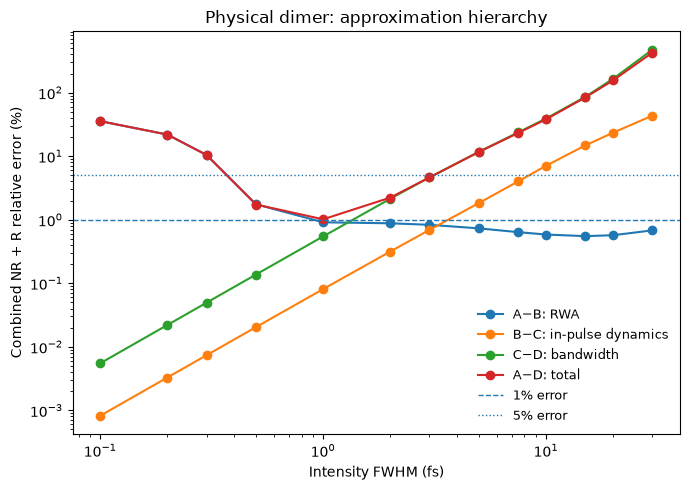

In [18]:
fwhm_vals = np.array([
    r["fwhm_fs"] for r in pulse_scan_full
])

AB_vals = 100 * np.array([
    r["AB"] for r in pulse_scan_full
])

BC_vals = 100 * np.array([
    r["BC"] for r in pulse_scan_full
])

CD_vals = 100 * np.array([
    r["CD"] for r in pulse_scan_full
])

AD_vals = 100 * np.array([
    r["AD"] for r in pulse_scan_full
])


fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

ax.plot(
    fwhm_vals,
    AB_vals,
    "o-",
    label="A−B: RWA",
)

ax.plot(
    fwhm_vals,
    BC_vals,
    "o-",
    label="B−C: in-pulse dynamics",
)

ax.plot(
    fwhm_vals,
    CD_vals,
    "o-",
    label="C−D: bandwidth",
)

ax.plot(
    fwhm_vals,
    AD_vals,
    "o-",
    label="A−D: total",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="1% error",
)

ax.axhline(
    5.0,
    linestyle=":",
    linewidth=1,
    label="5% error",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    "Intensity FWHM (fs)"
)

ax.set_ylabel(
    "Combined NR + R relative error (%)"
)

ax.set_title(
    "Physical dimer: approximation hierarchy"
)

ax.legend(
    frameon=False,
    fontsize=9,
)

fig.tight_layout()
plt.show()

In [19]:
def build_system_for_J(J_eV):
    J_omega_i = J_eV / HBAR_EV_FS

    model_i = build_dimer(
        omega_a=omega_a,
        omega_b=omega_b,
        J=J_omega_i,
        gamma_a=gamma_a,
        gamma_b=gamma_b,
        nbar_a=nbar_a,
        nbar_b=nbar_b,
        hbar=HBAR_EV_FS,
    )

    collapse_ops_i = [
        model_i["L_a_down"],
        model_i["L_a_up"],
        model_i["L_b_down"],
        model_i["L_b_up"],
    ]

    mu_plus_i = (
        model_i["sigma_a_plus"]
        + model_i["sigma_b_plus"]
    )

    mu_minus_i = (
        model_i["sigma_a_minus"]
        + model_i["sigma_b_minus"]
    )

    system_i = pulsus.SpectroscopySystem(
        H=model_i["H_S"],
        dipole=model_i["mu"],
        collapse_ops=collapse_ops_i,
        rho0=model_i["rho0"],
        hbar=HBAR_EV_FS,
        dipole_plus=mu_plus_i,
        dipole_minus=mu_minus_i,
    )

    DeltaE_i = np.sqrt(
        detuning**2
        + 4.0 * J_eV**2
    )

    return system_i, DeltaE_i

In [20]:
system_test, DeltaE_test = build_system_for_J(0.040)

print(
    "Splitting =",
    1000 * DeltaE_test,
    "meV"
)

print(
    "||L rho0|| =",
    np.linalg.norm(
        system_test.L
        @ pulsus.vec(system_test.rho0)
    )
)

Splitting = 89.44271909999159 meV
||L rho0|| = 0.0


In [21]:
def evaluate_BC_for_J_and_pulse(
    J_eV,
    intensity_fwhm_fs,
):
    # Build dimer for this coupling
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    # Pulse width
    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    # Normalize Gaussian spectral prefactor to 1
    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    # Keep pulse separation fixed in units of sigma
    T_i = 6.0 * sigma_i

    # --------------------------------------------------------
    # Nonrephasing
    # --------------------------------------------------------

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    C_NR = pulsus.short_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    # --------------------------------------------------------
    # Rephasing
    # --------------------------------------------------------

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    C_R = pulsus.short_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    eps_BC = combined_relative_error(
        C_NR, B_NR,
        C_R, B_R,
    )

    chi_dyn_i = (
        sigma_i
        * DeltaE_i
        / HBAR_EV_FS
    )

    return {
        "J_eV": J_eV,
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "DeltaE_eV": DeltaE_i,
        "chi_dyn": chi_dyn_i,
        "BC": eps_BC,
    }

In [22]:
test_BC = evaluate_BC_for_J_and_pulse(
    J_eV=0.040,
    intensity_fwhm_fs=20.0,
)

for key, value in test_BC.items():
    print(f"{key:10s}: {value}")

J_eV      : 0.04
fwhm_fs   : 20.0
sigma_fs  : 12.011224087864498
DeltaE_eV : 0.08944271909999159
chi_dyn   : 1.6321741513138972
BC        : 0.23448228487408607


In [23]:
# ------------------------------------------------------------
# Coarse J x pulse-duration scan for B-C
# ------------------------------------------------------------

J_scan = np.array([
    0.000,
    0.020,
    0.040,
    0.060,
    0.080,
    0.100,
])

fwhm_scan_BC = np.array([
    1.0,
    2.0,
    3.0,
    5.0,
    7.5,
    10.0,
    15.0,
    20.0,
    30.0,
])

BC_map = np.empty(
    (len(J_scan), len(fwhm_scan_BC))
)

chi_dyn_map = np.empty_like(
    BC_map
)

for i, J_i in enumerate(J_scan):
    for j, fwhm_i in enumerate(fwhm_scan_BC):

        result = evaluate_BC_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
        )

        BC_map[i, j] = result["BC"]
        chi_dyn_map[i, j] = result["chi_dyn"]

    print(
        f"Finished J = {1000*J_i:6.1f} meV"
    )

print()
print("BC scan complete.")
print("Shape:", BC_map.shape)
print(
    "Error range:",
    f"{100*np.min(BC_map):.4f}% to "
    f"{100*np.max(BC_map):.2f}%"
)

Finished J =    0.0 meV
Finished J =   20.0 meV
Finished J =   40.0 meV
Finished J =   60.0 meV
Finished J =   80.0 meV
Finished J =  100.0 meV

BC scan complete.
Shape: (6, 9)
Error range: 0.0609% to 46.37%


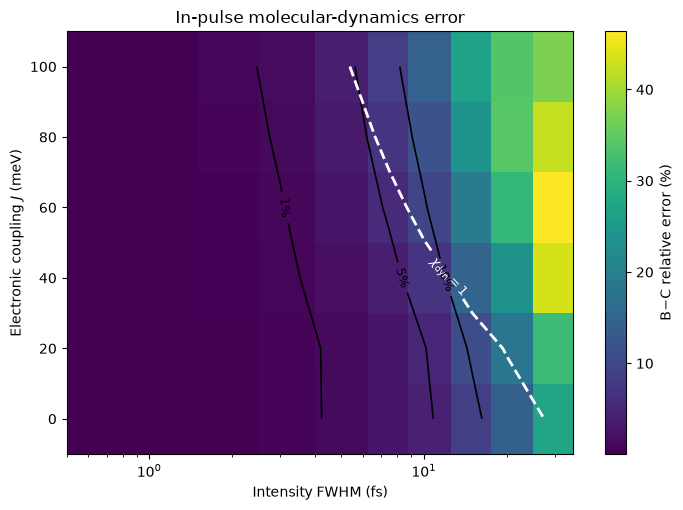

In [24]:
# ------------------------------------------------------------
# Coarse B-C regime map
# ------------------------------------------------------------

J_mesh, fwhm_mesh = np.meshgrid(
    1000.0 * J_scan,       # meV
    fwhm_scan_BC,          # fs
    indexing="ij",
)

BC_percent = 100.0 * BC_map


fig, ax = plt.subplots(
    figsize=(7.2, 5.2)
)

pcm = ax.pcolormesh(
    fwhm_mesh,
    J_mesh,
    BC_percent,
    shading="auto",
)

cbar = fig.colorbar(
    pcm,
    ax=ax,
)

cbar.set_label(
    "B−C relative error (%)"
)


# Error contours
cs_err = ax.contour(
    fwhm_mesh,
    J_mesh,
    BC_percent,
    levels=[1.0, 5.0, 10.0],
    colors="black",
    linewidths=1.2,
)

ax.clabel(
    cs_err,
    fmt=lambda x: f"{x:.0f}%",
    fontsize=9,
)


# chi_dyn = 1 boundary
cs_chi = ax.contour(
    fwhm_mesh,
    J_mesh,
    chi_dyn_map,
    levels=[1.0],
    colors="white",
    linestyles="--",
    linewidths=2.0,
)

ax.clabel(
    cs_chi,
    fmt={1.0: r"$\chi_{\rm dyn}=1$"},
    fontsize=9,
)


ax.set_xscale("log")

ax.set_xlabel(
    "Intensity FWHM (fs)"
)

ax.set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

ax.set_title(
    "In-pulse molecular-dynamics error"
)

fig.tight_layout()

plt.show()

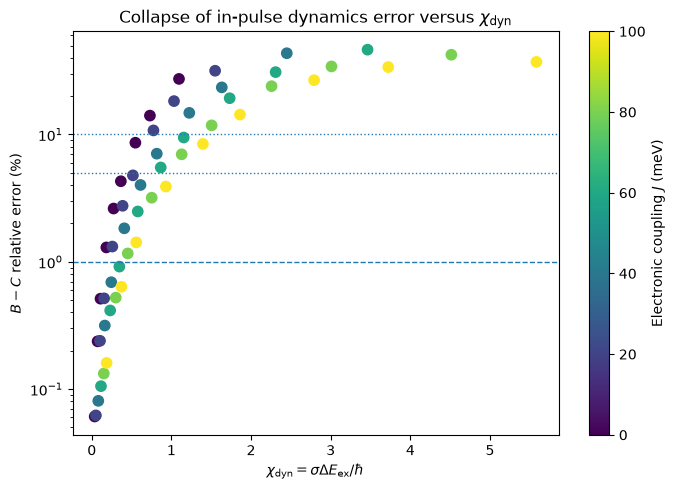

In [25]:
# ------------------------------------------------------------
# Collapse B-C error versus chi_dyn
# ------------------------------------------------------------

chi_vals = chi_dyn_map.ravel()
BC_vals = 100.0 * BC_map.ravel()

# Matching J value for every point
J_vals = np.repeat(
    1000.0 * J_scan,
    len(fwhm_scan_BC),
)

fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

sc = ax.scatter(
    chi_vals,
    BC_vals,
    c=J_vals,
    s=55,
)

cbar = fig.colorbar(
    sc,
    ax=ax,
)

cbar.set_label(
    r"Electronic coupling $J$ (meV)"
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    5.0,
    linestyle=":",
    linewidth=1,
)

ax.axhline(
    10.0,
    linestyle=":",
    linewidth=1,
)

ax.set_yscale("log")

ax.set_xlabel(
    r"$\chi_{\rm dyn} = "
    r"\sigma \Delta E_{\rm ex}/\hbar$"
)

ax.set_ylabel(
    r"$B-C$ relative error (%)"
)

ax.set_title(
    r"Collapse of in-pulse dynamics error versus $\chi_{\rm dyn}$"
)

fig.tight_layout()
plt.show()

In [26]:
def evaluate_BC_for_J_and_pulse(
    J_eV,
    intensity_fwhm_fs,
    T_fs,
):
    # Build dimer for this coupling
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    # Pulse width
    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    # Normalize Gaussian spectral prefactor to 1
    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    # --------------------------------------------------------
    # Nonrephasing
    # --------------------------------------------------------

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    C_NR = pulsus.short_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    # --------------------------------------------------------
    # Rephasing
    # --------------------------------------------------------

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    C_R = pulsus.short_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    eps_BC = combined_relative_error(
        C_NR, B_NR,
        C_R, B_R,
    )

    chi_dyn_i = (
        sigma_i
        * DeltaE_i
        / HBAR_EV_FS
    )

    return {
        "J_eV": J_eV,
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "T_fs": T_fs,
        "DeltaE_eV": DeltaE_i,
        "chi_dyn": chi_dyn_i,
        "BC": eps_BC,
    }

In [27]:
test_fixed_T = evaluate_BC_for_J_and_pulse(
    J_eV=0.040,
    intensity_fwhm_fs=20.0,
    T_fs=72.06734452718699,
)

for key, value in test_fixed_T.items():
    print(f"{key:10s}: {value}")

J_eV      : 0.04
fwhm_fs   : 20.0
sigma_fs  : 12.011224087864498
T_fs      : 72.06734452718699
DeltaE_eV : 0.08944271909999159
chi_dyn   : 1.6321741513138972
BC        : 0.23448228487408607


In [28]:
# ------------------------------------------------------------
# J x pulse-duration scan at fixed T = 100 fs
# ------------------------------------------------------------

T_fixed = 100.0  # fs

BC_map_T100 = np.empty(
    (len(J_scan), len(fwhm_scan_BC))
)

chi_dyn_map_T100 = np.empty_like(
    BC_map_T100
)

for i, J_i in enumerate(J_scan):
    for j, fwhm_i in enumerate(fwhm_scan_BC):

        result = evaluate_BC_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=T_fixed,
        )

        BC_map_T100[i, j] = result["BC"]
        chi_dyn_map_T100[i, j] = result["chi_dyn"]

    print(
        f"Finished J = {1000*J_i:6.1f} meV"
    )

print()
print("Fixed-T scan complete.")
print("Shape:", BC_map_T100.shape)
print(
    "Error range:",
    f"{100*np.min(BC_map_T100):.4f}% to "
    f"{100*np.max(BC_map_T100):.2f}%"
)

Finished J =    0.0 meV
Finished J =   20.0 meV
Finished J =   40.0 meV
Finished J =   60.0 meV
Finished J =   80.0 meV
Finished J =  100.0 meV

Fixed-T scan complete.
Shape: (6, 9)
Error range: 0.0591% to 46.43%


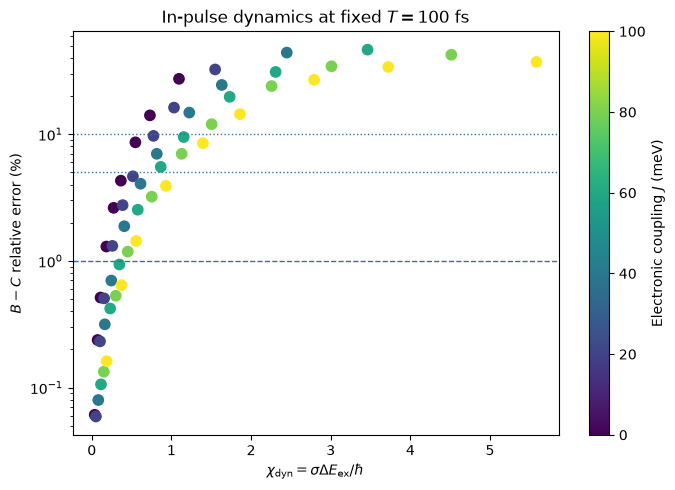

Maximum absolute change in B-C error: 2.087 percentage points
Mean absolute change in B-C error: 0.133 percentage points


In [29]:
# ------------------------------------------------------------
# chi_dyn collapse at fixed T = 100 fs
# ------------------------------------------------------------

chi_vals_T100 = chi_dyn_map_T100.ravel()
BC_vals_T100 = 100.0 * BC_map_T100.ravel()

J_vals_T100 = np.repeat(
    1000.0 * J_scan,
    len(fwhm_scan_BC),
)


fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

sc = ax.scatter(
    chi_vals_T100,
    BC_vals_T100,
    c=J_vals_T100,
    s=55,
)

cbar = fig.colorbar(
    sc,
    ax=ax,
)

cbar.set_label(
    r"Electronic coupling $J$ (meV)"
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    5.0,
    linestyle=":",
    linewidth=1,
)

ax.axhline(
    10.0,
    linestyle=":",
    linewidth=1,
)

ax.set_yscale("log")

ax.set_xlabel(
    r"$\chi_{\rm dyn} = "
    r"\sigma \Delta E_{\rm ex}/\hbar$"
)

ax.set_ylabel(
    r"$B-C$ relative error (%)"
)

ax.set_title(
    r"In-pulse dynamics at fixed $T=100$ fs"
)

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# Compare with the previous T = 6 sigma scan
# ------------------------------------------------------------

difference_percentage_points = (
    100.0 * (BC_map_T100 - BC_map)
)

print(
    "Maximum absolute change in B-C error:",
    f"{np.max(np.abs(difference_percentage_points)):.3f}",
    "percentage points",
)

print(
    "Mean absolute change in B-C error:",
    f"{np.mean(np.abs(difference_percentage_points)):.3f}",
    "percentage points",
)

## 5. Independent breakdown of the RWA

The \(B-C\) comparison isolates molecular evolution during the pulse.

We now examine the complementary approximation,

\[
A-B,
\]

which isolates the molecular rotating-wave approximation while retaining
the same finite Gaussian pulses.

All regime scans from this point use a fixed waiting time,

\[
T=100\ {\rm fs}.
\]

In [30]:
def evaluate_AB_for_J_and_pulse(
    J_eV,
    intensity_fwhm_fs,
    T_fs=100.0,
):
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    # Nonrephasing
    A_NR = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    # Rephasing
    A_R = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    eps_AB = combined_relative_error(
        B_NR, A_NR,
        B_R, A_R,
    )

    chi_dyn_i = (
        sigma_i
        * DeltaE_i
        / HBAR_EV_FS
    )

    chi_RWA_i = (
        2.0
        * sigma_i
        * omega_L
    )

    return {
        "J_eV": J_eV,
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "chi_dyn": chi_dyn_i,
        "chi_RWA": chi_RWA_i,
        "AB": eps_AB,
    }

In [31]:
test_AB = evaluate_AB_for_J_and_pulse(
    J_eV=0.040,
    intensity_fwhm_fs=0.10,
)

for key, value in test_AB.items():
    print(f"{key:10s}: {value}")

J_eV      : 0.04
fwhm_fs   : 0.1
sigma_fs  : 0.0600561204393225
chi_dyn   : 0.008160870756569488
chi_RWA   : 0.3649652353455903
AB        : 0.3077394144364851


In [32]:
# ------------------------------------------------------------
# Coarse J x pulse-duration scan for A-B at fixed T = 100 fs
# ------------------------------------------------------------

fwhm_scan_AB = np.array([
    0.10,
    0.20,
    0.30,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
    3.00,
    5.00,
])

AB_map_T100 = np.empty(
    (len(J_scan), len(fwhm_scan_AB))
)

chi_RWA_map = np.empty_like(
    AB_map_T100
)

chi_dyn_AB_map = np.empty_like(
    AB_map_T100
)

for i, J_i in enumerate(J_scan):
    for j, fwhm_i in enumerate(fwhm_scan_AB):

        result = evaluate_AB_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=100.0,
        )

        AB_map_T100[i, j] = result["AB"]
        chi_RWA_map[i, j] = result["chi_RWA"]
        chi_dyn_AB_map[i, j] = result["chi_dyn"]

    print(
        f"Finished J = {1000*J_i:6.1f} meV"
    )

print()
print("A-B scan complete.")
print("Shape:", AB_map_T100.shape)
print(
    "Error range:",
    f"{100*np.min(AB_map_T100):.3f}% to "
    f"{100*np.max(AB_map_T100):.2f}%"
)

Finished J =    0.0 meV
Finished J =   20.0 meV
Finished J =   40.0 meV
Finished J =   60.0 meV
Finished J =   80.0 meV
Finished J =  100.0 meV

A-B scan complete.
Shape: (6, 10)
Error range: 0.727% to 33.37%


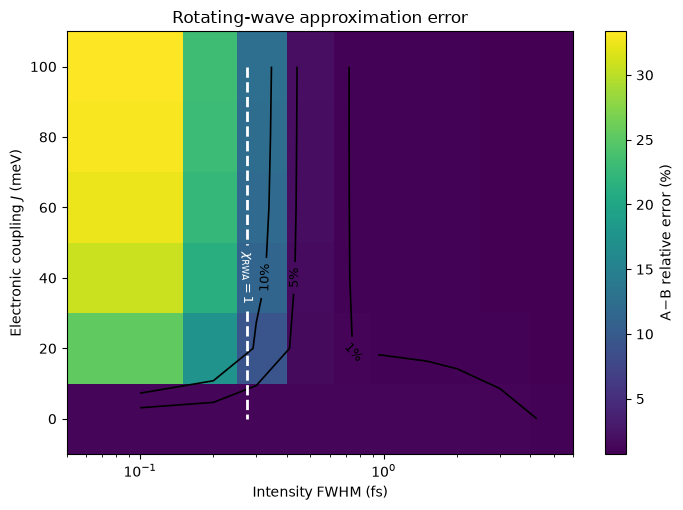

In [33]:
# ------------------------------------------------------------
# A-B RWA regime map
# ------------------------------------------------------------

J_mesh_AB, fwhm_mesh_AB = np.meshgrid(
    1000.0 * J_scan,
    fwhm_scan_AB,
    indexing="ij",
)

AB_percent = 100.0 * AB_map_T100


fig, ax = plt.subplots(
    figsize=(7.2, 5.2)
)

pcm = ax.pcolormesh(
    fwhm_mesh_AB,
    J_mesh_AB,
    AB_percent,
    shading="auto",
)

cbar = fig.colorbar(
    pcm,
    ax=ax,
)

cbar.set_label(
    "A−B relative error (%)"
)


# Numerical error contours
cs_err = ax.contour(
    fwhm_mesh_AB,
    J_mesh_AB,
    AB_percent,
    levels=[1.0, 5.0, 10.0],
    colors="black",
    linewidths=1.2,
)

ax.clabel(
    cs_err,
    fmt=lambda x: f"{x:.0f}%",
    fontsize=9,
)


# chi_RWA = 1 theoretical boundary
cs_rwa = ax.contour(
    fwhm_mesh_AB,
    J_mesh_AB,
    chi_RWA_map,
    levels=[1.0],
    colors="white",
    linestyles="--",
    linewidths=2.0,
)

ax.clabel(
    cs_rwa,
    fmt={1.0: r"$\chi_{\rm RWA}=1$"},
    fontsize=9,
)


ax.set_xscale("log")

ax.set_xlabel(
    "Intensity FWHM (fs)"
)

ax.set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

ax.set_title(
    "Rotating-wave approximation error"
)

fig.tight_layout()
plt.show()

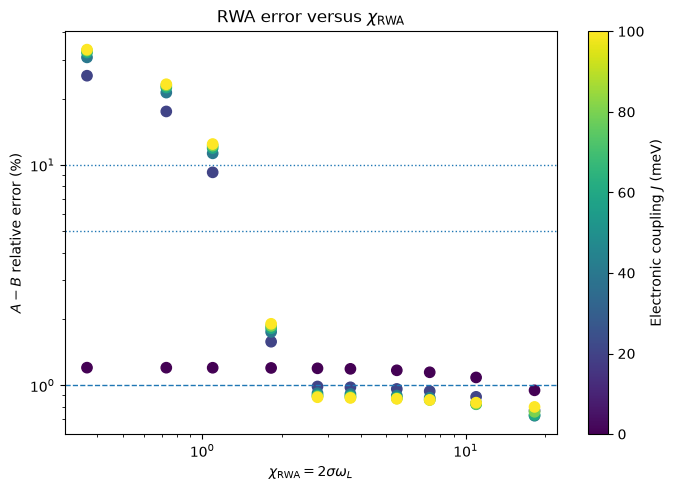

In [34]:
# ------------------------------------------------------------
# Collapse A-B error versus chi_RWA
# ------------------------------------------------------------

chi_RWA_vals = chi_RWA_map.ravel()
AB_vals = 100.0 * AB_map_T100.ravel()

J_vals_AB = np.repeat(
    1000.0 * J_scan,
    len(fwhm_scan_AB),
)

fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

sc = ax.scatter(
    chi_RWA_vals,
    AB_vals,
    c=J_vals_AB,
    s=55,
)

cbar = fig.colorbar(
    sc,
    ax=ax,
)

cbar.set_label(
    r"Electronic coupling $J$ (meV)"
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    5.0,
    linestyle=":",
    linewidth=1,
)

ax.axhline(
    10.0,
    linestyle=":",
    linewidth=1,
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(
    r"$\chi_{\rm RWA} = 2\sigma\omega_L$"
)

ax.set_ylabel(
    r"$A-B$ relative error (%)"
)

ax.set_title(
    r"RWA error versus $\chi_{\rm RWA}$"
)

fig.tight_layout()
plt.show()

In [35]:
print("A-B relative error (%)")
print()

header = "J (meV)  " + "  ".join(
    f"{x:>7.2f} fs"
    for x in fwhm_scan_AB
)

print(header)

for i, J_i in enumerate(J_scan):
    row = "  ".join(
        f"{100*AB_map_T100[i, j]:7.3f}"
        for j in range(len(fwhm_scan_AB))
    )

    print(
        f"{1000*J_i:7.1f}  {row}"
    )

A-B relative error (%)

J (meV)     0.10 fs     0.20 fs     0.30 fs     0.50 fs     0.75 fs     1.00 fs     1.50 fs     2.00 fs     3.00 fs     5.00 fs
    0.0    1.202    1.202    1.201    1.199    1.194    1.188    1.170    1.146    1.086    0.949
   20.0   25.410   17.493    9.257    1.577    0.988    0.979    0.963    0.941    0.886    0.768
   40.0   30.774   21.302   11.292    1.746    0.921    0.913    0.898    0.879    0.831    0.727
   60.0   32.384   22.461   11.933    1.816    0.900    0.892    0.879    0.862    0.820    0.733
   80.0   33.033   22.958   12.240    1.862    0.890    0.882    0.872    0.858    0.824    0.758
  100.0   33.371   23.246   12.443    1.902    0.883    0.876    0.868    0.858    0.834    0.798


In [36]:
# ------------------------------------------------------------
# Small-J diagnostic at ultrashort pulse duration
# ------------------------------------------------------------

J_small_meV = np.array([
    0.0,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
])

fwhm_test = 0.10  # fs

print(
    "Small-J RWA diagnostic "
    f"at FWHM = {fwhm_test:.2f} fs"
)
print("--------------------------------")

for J_meV in J_small_meV:
    result = evaluate_AB_for_J_and_pulse(
        J_eV=J_meV / 1000.0,
        intensity_fwhm_fs=fwhm_test,
        T_fs=100.0,
    )

    print(
        f"J = {J_meV:5.1f} meV   "
        f"chi_dyn = {result['chi_dyn']:7.4f}   "
        f"chi_RWA = {result['chi_RWA']:7.4f}   "
        f"AB = {100*result['AB']:8.3f}%"
    )

Small-J RWA diagnostic at FWHM = 0.10 fs
--------------------------------
J =   0.0 meV   chi_dyn =  0.0036   chi_RWA =  0.3650   AB =    1.202%
J =   1.0 meV   chi_dyn =  0.0037   chi_RWA =  0.3650   AB =    3.083%
J =   2.0 meV   chi_dyn =  0.0037   chi_RWA =  0.3650   AB =    5.690%
J =   5.0 meV   chi_dyn =  0.0038   chi_RWA =  0.3650   AB =   12.568%
J =  10.0 meV   chi_dyn =  0.0041   chi_RWA =  0.3650   AB =   19.543%
J =  20.0 meV   chi_dyn =  0.0052   chi_RWA =  0.3650   AB =   25.410%


In [37]:
# ------------------------------------------------------------
# Diagnose the small-J dependence of the RWA error
# ------------------------------------------------------------

J_small_meV = np.array([
    0.0,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
])

fwhm_test = 0.10
sigma_test = (
    fwhm_test
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_test = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_test
    )
)

pulse_test = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_test,
    E0=E0_test,
)

print(
    "J (meV)      ||A||        ||A-B||      relative"
)
print(
    "------------------------------------------------"
)

for J_meV in J_small_meV:

    system_i, _ = build_system_for_J(
        J_meV / 1000.0
    )

    # NR
    A_NR = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
    )

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
    )

    # R
    A_R = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="R",
    )

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="R",
    )

    norm_A = np.sqrt(
        np.linalg.norm(A_NR)**2
        + np.linalg.norm(A_R)**2
    )

    norm_diff = np.sqrt(
        np.linalg.norm(B_NR - A_NR)**2
        + np.linalg.norm(B_R - A_R)**2
    )

    print(
        f"{J_meV:7.1f}   "
        f"{norm_A:11.4e}   "
        f"{norm_diff:11.4e}   "
        f"{100*norm_diff/norm_A:8.3f}%"
    )

J (meV)      ||A||        ||A-B||      relative
------------------------------------------------
    0.0    1.2393e+05    1.4903e+03      1.202%
    1.0    1.2505e+05    3.8555e+03      3.083%
    2.0    1.2756e+05    7.2581e+03      5.690%
    5.0    1.4246e+05    1.7904e+04     12.568%
   10.0    1.8390e+05    3.5941e+04     19.543%
   20.0    2.6703e+05    6.7854e+04     25.410%


In [38]:
# ------------------------------------------------------------
# Branch-resolved RWA error at FWHM = 0.10 fs
# ------------------------------------------------------------

print(
    "J (meV)      NR error      R error      combined"
)
print(
    "------------------------------------------------"
)

for J_meV in J_small_meV:

    system_i, _ = build_system_for_J(
        J_meV / 1000.0
    )

    # Nonrephasing
    A_NR = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
    )

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
    )

    # Rephasing
    A_R = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="R",
    )

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_i,
        pulse1=pulse_test,
        pulse2=pulse_test,
        pulse3=pulse_test,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="R",
    )

    err_NR = relative_error(
        B_NR,
        A_NR,
    )

    err_R = relative_error(
        B_R,
        A_R,
    )

    err_comb = combined_relative_error(
        B_NR, A_NR,
        B_R, A_R,
    )

    print(
        f"{J_meV:7.1f}   "
        f"{100*err_NR:9.3f}%   "
        f"{100*err_R:9.3f}%   "
        f"{100*err_comb:9.3f}%"
    )

J (meV)      NR error      R error      combined
------------------------------------------------
    0.0       1.213%       1.194%       1.202%
    1.0       4.360%       1.204%       3.083%
    2.0       8.255%       1.209%       5.690%
    5.0      18.098%       1.196%      12.568%
   10.0      27.543%       1.133%      19.543%
   20.0      34.804%       1.076%      25.410%


In [39]:
# ------------------------------------------------------------
# Waiting-time dependence of branch-resolved RWA error
# ------------------------------------------------------------

J_test_eV = 0.020
fwhm_test = 0.10

sigma_test = (
    fwhm_test
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_test = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_test
    )
)

pulse_test_T = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_test,
    E0=E0_test,
)

system_test_T, _ = build_system_for_J(
    J_test_eV
)

T_scan = [
    1.0,
    5.0,
    10.0,
    25.0,
    50.0,
    100.0,
]

print(
    "T (fs)      NR error      R error      combined"
)
print(
    "------------------------------------------------"
)

for T_i in T_scan:

    # Nonrephasing
    A_NR = pulsus.finite_pulse_spectrum(
        system=system_test_T,
        pulse1=pulse_test_T,
        pulse2=pulse_test_T,
        pulse3=pulse_test_T,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    B_NR = pulsus.finite_pulse_rwa_spectrum(
        system=system_test_T,
        pulse1=pulse_test_T,
        pulse2=pulse_test_T,
        pulse3=pulse_test_T,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="NR",
    )

    # Rephasing
    A_R = pulsus.finite_pulse_spectrum(
        system=system_test_T,
        pulse1=pulse_test_T,
        pulse2=pulse_test_T,
        pulse3=pulse_test_T,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    B_R = pulsus.finite_pulse_rwa_spectrum(
        system=system_test_T,
        pulse1=pulse_test_T,
        pulse2=pulse_test_T,
        pulse3=pulse_test_T,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_i,
        eta=eta,
        pathway="R",
    )

    err_NR = relative_error(
        B_NR,
        A_NR,
    )

    err_R = relative_error(
        B_R,
        A_R,
    )

    err_comb = combined_relative_error(
        B_NR, A_NR,
        B_R, A_R,
    )

    print(
        f"{T_i:6.1f}   "
        f"{100*err_NR:9.3f}%   "
        f"{100*err_R:9.3f}%   "
        f"{100*err_comb:9.3f}%"
    )

T (fs)      NR error      R error      combined
------------------------------------------------
   1.0      28.628%       1.277%      22.942%
   5.0      30.526%       1.210%      23.834%
  10.0      39.720%       0.976%      27.370%
  25.0      32.584%       1.107%      24.413%
  50.0      48.413%       0.832%      30.043%
 100.0      34.804%       1.076%      25.410%


In [40]:
# ------------------------------------------------------------
# Absolute NR/R norms at the representative ultrashort point
# ------------------------------------------------------------

J_diag = 0.020
T_diag = 100.0
fwhm_diag = 0.10

sigma_diag = (
    fwhm_diag
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_diag = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_diag
    )
)

pulse_diag = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_diag,
    E0=E0_diag,
)

system_diag, _ = build_system_for_J(
    J_diag
)


# Nonrephasing
A_NR_diag = pulsus.finite_pulse_spectrum(
    system=system_diag,
    pulse1=pulse_diag,
    pulse2=pulse_diag,
    pulse3=pulse_diag,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T_diag,
    eta=eta,
    pathway="NR",
)

B_NR_diag = pulsus.finite_pulse_rwa_spectrum(
    system=system_diag,
    pulse1=pulse_diag,
    pulse2=pulse_diag,
    pulse3=pulse_diag,
    omega1=omega1_grid,
    omega3=omega3_grid,
    T=T_diag,
    eta=eta,
    pathway="NR",
)


# Rephasing
A_R_diag = pulsus.finite_pulse_spectrum(
    system=system_diag,
    pulse1=pulse_diag,
    pulse2=pulse_diag,
    pulse3=pulse_diag,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T_diag,
    eta=eta,
    pathway="R",
)

B_R_diag = pulsus.finite_pulse_rwa_spectrum(
    system=system_diag,
    pulse1=pulse_diag,
    pulse2=pulse_diag,
    pulse3=pulse_diag,
    omega1=omega1_grid_R,
    omega3=omega3_grid,
    T=T_diag,
    eta=eta,
    pathway="R",
)


print("Branch      ||A||          ||A-B||       relative")
print("----------------------------------------------------")

for label, A_i, B_i in [
    ("NR", A_NR_diag, B_NR_diag),
    ("R ", A_R_diag, B_R_diag),
]:
    norm_A = np.linalg.norm(A_i)
    norm_diff = np.linalg.norm(A_i - B_i)

    print(
        f"{label:3s}   "
        f"{norm_A:12.4e}   "
        f"{norm_diff:12.4e}   "
        f"{100*norm_diff/norm_A:8.3f}%"
    )

Branch      ||A||          ||A-B||       relative
----------------------------------------------------
NR      1.9488e+05     6.7826e+04     34.804%
R       1.8256e+05     1.9635e+03      1.076%


In [41]:
# ------------------------------------------------------------
# Check interaction-operator decomposition
# ------------------------------------------------------------

V_reconstructed = (
    system_diag.V_plus
    + system_diag.V_minus
)

print(
    "||V - (V_plus + V_minus)|| =",
    np.linalg.norm(
        system_diag.V - V_reconstructed
    ),
)

print(
    "||V|| =",
    np.linalg.norm(system_diag.V),
)

||V - (V_plus + V_minus)|| = 0.0
||V|| = 12.15413958396902


In [42]:
from scipy.linalg import expm

from pulsus.liouville import vec
from pulsus.pulses import (
    pulse_dressing_1,
    pulse_dressing_2,
    pulse_dressing_3,
)
from pulsus.resolvents import resolvent_action
from pulsus.response import (
    observable_bra,
    resolve_signature,
)

In [43]:
def finite_pulse_molecular_sequence_spectrum(
    system,
    pulse1,
    pulse2,
    pulse3,
    omega1,
    omega3,
    T,
    eta,
    pathway,
    molecular_signature,
    rho0=None,
):
    """
    Finite-pulse spectrum for one selected molecular
    V_+/V_- interaction sequence.

    The field signature is still determined by `pathway`.
    `molecular_signature` selects V_+ or V_- independently
    at the three molecular interactions.
    """

    omega1 = np.asarray(omega1, dtype=float)
    omega3 = np.asarray(omega3, dtype=float)

    if rho0 is None:
        rho0 = system.rho0

    L = np.asarray(
        system.L,
        dtype=complex,
    )

    rho_vec = vec(rho0)

    mu_bra = observable_bra(
        system.dipole
    )

    # Field signs: fixed by NR/R phase matching
    q1, q2, q3 = resolve_signature(
        pathway=pathway,
        signature=None,
    )

    # Molecular interaction signs: varied independently
    m1, m2, m3 = molecular_signature

    def interaction(sign):
        if sign == 1:
            return system.V_plus
        return system.V_minus

    V1 = interaction(m1)
    V2 = interaction(m2)
    V3 = interaction(m3)

    n = L.shape[0]

    U_T = expm(
        L * T
    )

    # --------------------------------------------------------
    # omega1-dependent side
    # --------------------------------------------------------

    right = np.empty(
        (n, omega1.size),
        dtype=complex,
    )

    for i, w1 in enumerate(omega1):

        F1 = pulse_dressing_1(
            L_super=L,
            omega1=w1,
            omega_L=pulse1.omega_L,
            sigma=pulse1.sigma,
            E0=pulse1.E0,
            phase=pulse1.phase,
            sign=q1,
        )

        F2 = pulse_dressing_2(
            L_super=L,
            omega1=w1,
            omega_L=pulse2.omega_L,
            sigma=pulse2.sigma,
            E0=pulse2.E0,
            phase=pulse2.phase,
            sign=q2,
        )

        state = F1 @ rho_vec
        state = V1 @ state

        state = resolvent_action(
            L_super=L,
            omega=w1,
            rhs=state,
            eta=eta,
        )

        state = V2 @ state
        state = F2 @ state

        right[:, i] = state

    # --------------------------------------------------------
    # omega3-dependent side
    # --------------------------------------------------------

    left = np.empty(
        (omega3.size, n),
        dtype=complex,
    )

    for j, w3 in enumerate(omega3):

        F3 = pulse_dressing_3(
            L_super=L,
            omega3=w3,
            omega_L=pulse3.omega_L,
            sigma=pulse3.sigma,
            E0=pulse3.E0,
            phase=pulse3.phase,
            sign=q3,
        )

        bra_G3 = resolvent_action(
            L_super=L.T,
            omega=w3,
            rhs=mu_bra,
            eta=eta,
        )

        left[j, :] = (
            bra_G3
            @ V3
            @ U_T
            @ F3
        )

    return left @ right

In [44]:
# ------------------------------------------------------------
# Decompose full NR Model A into all 8 molecular sequences
# ------------------------------------------------------------

molecular_sequences = [
    (+1, +1, +1),
    (+1, +1, -1),
    (+1, -1, +1),
    (+1, -1, -1),
    (-1, +1, +1),
    (-1, +1, -1),
    (-1, -1, +1),
    (-1, -1, -1),
]

sequence_spectra_NR = {}

for seq in molecular_sequences:

    S_seq = finite_pulse_molecular_sequence_spectrum(
        system=system_diag,
        pulse1=pulse_diag,
        pulse2=pulse_diag,
        pulse3=pulse_diag,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_diag,
        eta=eta,
        pathway="NR",
        molecular_signature=seq,
    )

    sequence_spectra_NR[seq] = S_seq


# Sum all 8 terms
A_NR_reconstructed = sum(
    sequence_spectra_NR.values()
)


print(
    "Reconstruction error =",
    np.linalg.norm(
        A_NR_reconstructed - A_NR_diag
    )
    / np.linalg.norm(A_NR_diag)
)

print(
    "RWA-sequence error =",
    np.linalg.norm(
        sequence_spectra_NR[(+1, -1, +1)]
        - B_NR_diag
    )
    / np.linalg.norm(B_NR_diag)
)

Reconstruction error = 8.33733820440058e-16
RWA-sequence error = 0.0


In [45]:
# ------------------------------------------------------------
# Rank molecular sequences contributing to NR beyond-RWA signal
# ------------------------------------------------------------

rwa_seq_NR = (+1, -1, +1)

Delta_NR = (
    A_NR_diag
    - B_NR_diag
)

norm_A_NR = np.linalg.norm(
    A_NR_diag
)

norm_B_NR = np.linalg.norm(
    B_NR_diag
)

norm_Delta_NR = np.linalg.norm(
    Delta_NR
)


def seq_label(seq):
    return "".join(
        "+" if s == 1 else "-"
        for s in seq
    )


rows = []

for seq in molecular_sequences:

    S_seq = sequence_spectra_NR[seq]

    seq_norm = np.linalg.norm(
        S_seq
    )

    # Real projection onto the total beyond-RWA correction.
    # For the 7 non-RWA terms these projections sum to 1.
    projection = (
        np.real(
            np.vdot(
                Delta_NR,
                S_seq,
            )
        )
        / norm_Delta_NR**2
    )

    rows.append(
        (
            seq_label(seq),
            seq_norm,
            100.0 * seq_norm / norm_A_NR,
            100.0 * seq_norm / norm_B_NR,
            projection,
        )
    )


# Sort by sequence norm, largest first
rows.sort(
    key=lambda x: x[1],
    reverse=True,
)


print(
    "seq      ||S_seq||      % of ||A||    "
    "% of ||B||    projection on Delta"
)
print(
    "-------------------------------------------------------------"
)

for label, norm_seq, pct_A, pct_B, proj in rows:

    marker = "  <-- RWA" if label == "+-+" else ""

    print(
        f"{label:3s}   "
        f"{norm_seq:11.4e}   "
        f"{pct_A:10.3f}%   "
        f"{pct_B:10.3f}%   "
        f"{proj:10.4f}"
        f"{marker}"
    )


print()
print(
    "Sum of non-RWA projections =",
    sum(
        row[4]
        for row in rows
        if row[0] != "+-+"
    )
)

seq      ||S_seq||      % of ||A||    % of ||B||    projection on Delta
-------------------------------------------------------------
+-+    1.8156e+05       93.167%      100.000%       0.0449  <-- RWA
++-    6.7467e+04       34.620%       37.159%       0.9944
-++    1.5860e+03        0.814%        0.874%       0.0055
+--    8.6765e+02        0.445%        0.478%       0.0001
-+-    8.1414e+00        0.004%        0.004%       0.0000
--+    7.2762e-02        0.000%        0.000%       0.0000
+++    0.0000e+00        0.000%        0.000%       0.0000
---    0.0000e+00        0.000%        0.000%       0.0000

Sum of non-RWA projections = 0.9999999999999974


In [46]:
# ------------------------------------------------------------
# Decompose full R Model A into all 8 molecular sequences
# ------------------------------------------------------------

sequence_spectra_R = {}

for seq in molecular_sequences:

    S_seq = finite_pulse_molecular_sequence_spectrum(
        system=system_diag,
        pulse1=pulse_diag,
        pulse2=pulse_diag,
        pulse3=pulse_diag,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_diag,
        eta=eta,
        pathway="R",
        molecular_signature=seq,
    )

    sequence_spectra_R[seq] = S_seq


A_R_reconstructed = sum(
    sequence_spectra_R.values()
)

print(
    "Reconstruction error =",
    np.linalg.norm(
        A_R_reconstructed - A_R_diag
    )
    / np.linalg.norm(A_R_diag)
)

print(
    "RWA-sequence error =",
    np.linalg.norm(
        sequence_spectra_R[(-1, +1, +1)]
        - B_R_diag
    )
    / np.linalg.norm(B_R_diag)
)

Reconstruction error = 8.6707389952447e-16
RWA-sequence error = 0.0


In [47]:
# ------------------------------------------------------------
# Rank molecular sequences contributing to R beyond-RWA signal
# ------------------------------------------------------------

rwa_seq_R = (-1, +1, +1)

Delta_R = (
    A_R_diag
    - B_R_diag
)

norm_A_R = np.linalg.norm(
    A_R_diag
)

norm_B_R = np.linalg.norm(
    B_R_diag
)

norm_Delta_R = np.linalg.norm(
    Delta_R
)

rows_R = []

for seq in molecular_sequences:

    S_seq = sequence_spectra_R[seq]

    seq_norm = np.linalg.norm(
        S_seq
    )

    projection = (
        np.real(
            np.vdot(
                Delta_R,
                S_seq,
            )
        )
        / norm_Delta_R**2
    )

    rows_R.append(
        (
            seq_label(seq),
            seq_norm,
            100.0 * seq_norm / norm_A_R,
            100.0 * seq_norm / norm_B_R,
            projection,
        )
    )

rows_R.sort(
    key=lambda x: x[1],
    reverse=True,
)

print(
    "seq      ||S_seq||      % of ||A||    "
    "% of ||B||    projection on Delta"
)
print(
    "-------------------------------------------------------------"
)

for label, norm_seq, pct_A, pct_B, proj in rows_R:

    marker = "  <-- RWA" if label == "-++" else ""

    print(
        f"{label:3s}   "
        f"{norm_seq:11.4e}   "
        f"{pct_A:10.3f}%   "
        f"{pct_B:10.3f}%   "
        f"{proj:10.4f}"
        f"{marker}"
    )

print()
print(
    "Sum of non-RWA projections =",
    sum(
        row[4]
        for row in rows_R
        if row[0] != "-++"
    )
)

seq      ||S_seq||      % of ||A||    % of ||B||    projection on Delta
-------------------------------------------------------------
-++    1.8244e+05       99.932%      100.000%       5.3968  <-- RWA
+-+    1.5858e+03        0.869%        0.869%       0.6755
-+-    8.6764e+02        0.475%        0.476%       0.2066
++-    6.3171e+02        0.346%        0.346%       0.1175
+--    8.1414e+00        0.004%        0.004%       0.0001
--+    7.7710e+00        0.004%        0.004%       0.0003
+++    0.0000e+00        0.000%        0.000%       0.0000
---    0.0000e+00        0.000%        0.000%       0.0000

Sum of non-RWA projections = 1.000000000000002


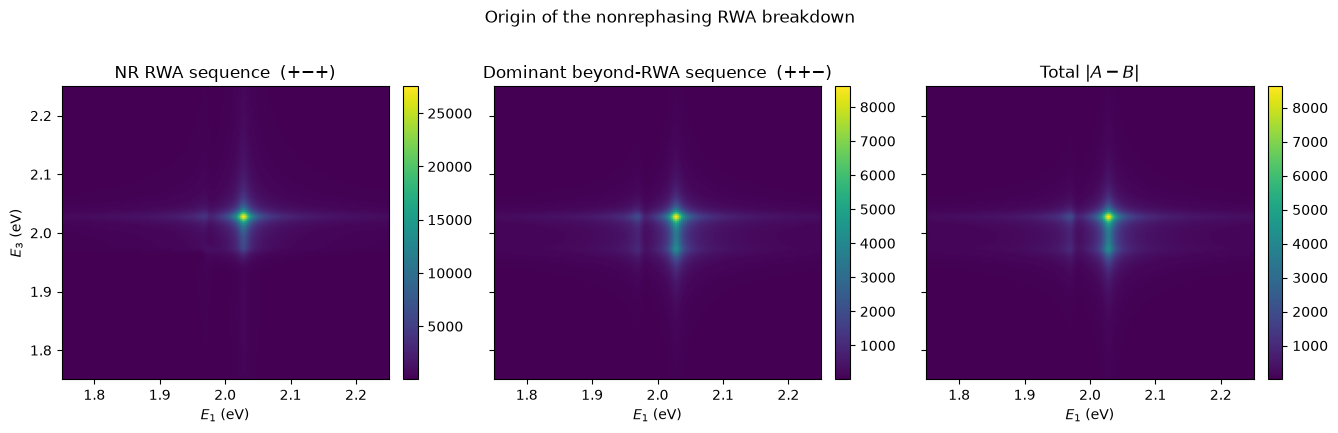

In [48]:
# ------------------------------------------------------------
# Spatial structure of the dominant NR beyond-RWA channel
# ------------------------------------------------------------

S_rwa_NR = sequence_spectra_NR[(+1, -1, +1)]
S_cr_NR = sequence_spectra_NR[(+1, +1, -1)]

Delta_NR = A_NR_diag - B_NR_diag

extent = [
    E1_grid[0],
    E1_grid[-1],
    E3_grid[0],
    E3_grid[-1],
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    sharex=True,
    sharey=True,
)

panels = [
    (
        np.abs(S_rwa_NR),
        "NR RWA sequence  (+−+)",
    ),
    (
        np.abs(S_cr_NR),
        "Dominant beyond-RWA sequence  (++−)",
    ),
    (
        np.abs(Delta_NR),
        r"Total $|A-B|$",
    ),
]

for ax, (data, title) in zip(axes, panels):

    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        aspect="auto",
    )

    ax.set_title(title)
    ax.set_xlabel(r"$E_1$ (eV)")

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

axes[0].set_ylabel(
    r"$E_3$ (eV)"
)

fig.suptitle(
    "Origin of the nonrephasing RWA breakdown",
    y=1.02,
)

fig.tight_layout()
plt.show()

In [49]:
# ------------------------------------------------------------
# Is the dominant beyond-RWA term just a complex rescaling
# of the NR RWA spectrum?
# ------------------------------------------------------------

S_rwa = sequence_spectra_NR[(+1, -1, +1)]
S_cr  = sequence_spectra_NR[(+1, +1, -1)]

# Best complex coefficient:
# S_cr ≈ beta * S_rwa
beta = (
    np.vdot(S_rwa, S_cr)
    / np.vdot(S_rwa, S_rwa)
)

residual = (
    np.linalg.norm(
        S_cr - beta * S_rwa
    )
    / np.linalg.norm(S_cr)
)

normalized_overlap = (
    np.vdot(S_rwa, S_cr)
    / (
        np.linalg.norm(S_rwa)
        * np.linalg.norm(S_cr)
    )
)

print(
    "beta =",
    beta,
)

print(
    "|beta| =",
    abs(beta),
)

print(
    "phase(beta) =",
    np.degrees(np.angle(beta)),
    "deg",
)

print(
    "normalized overlap magnitude =",
    abs(normalized_overlap),
)

print(
    "residual after optimal complex rescaling =",
    100 * residual,
    "%"
)

beta = (0.006328785329375503+0.34924037234880073j)
|beta| = 0.3492977114183176
phase(beta) = 88.96182391162581 deg
normalized overlap magnitude = 0.940007967346698
residual after optimal complex rescaling = 34.11524898410179 %


In [50]:
# ------------------------------------------------------------
# Growth of the dominant NR beyond-RWA sequence with coupling
# ------------------------------------------------------------

J_pathway_meV = np.array([
    0.0,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
    40.0,
])

print(
    "J (meV)      ||+-+||        ||++-||       "
    "||++-|| / ||+-+||"
)
print(
    "----------------------------------------------------------"
)

for J_meV in J_pathway_meV:

    system_i, _ = build_system_for_J(
        J_meV / 1000.0
    )

    S_rwa_i = finite_pulse_molecular_sequence_spectrum(
        system=system_i,
        pulse1=pulse_diag,
        pulse2=pulse_diag,
        pulse3=pulse_diag,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
        molecular_signature=(+1, -1, +1),
    )

    S_cr_i = finite_pulse_molecular_sequence_spectrum(
        system=system_i,
        pulse1=pulse_diag,
        pulse2=pulse_diag,
        pulse3=pulse_diag,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=100.0,
        eta=eta,
        pathway="NR",
        molecular_signature=(+1, +1, -1),
    )

    norm_rwa = np.linalg.norm(S_rwa_i)
    norm_cr = np.linalg.norm(S_cr_i)

    print(
        f"{J_meV:7.1f}   "
        f"{norm_rwa:11.4e}   "
        f"{norm_cr:11.4e}   "
        f"{100*norm_cr/norm_rwa:10.3f}%"
    )

J (meV)      ||+-+||        ||++-||       ||++-|| / ||+-+||
----------------------------------------------------------
    0.0    8.3566e+04    5.6126e-12        0.000%
    1.0    8.4089e+04    3.5152e+03        4.180%
    2.0    8.5636e+04    7.0385e+03        8.219%
    5.0    9.5570e+04    1.7707e+04       18.527%
   10.0    1.2319e+05    3.5674e+04       28.959%
   20.0    1.8156e+05    6.7467e+04       37.159%
   40.0    2.2378e+05    1.0117e+05       45.207%


### Coupling-induced nonrephasing beyond-RWA channel

The strong coupling dependence of the finite-pulse RWA error originates
almost entirely from the nonrephasing branch.

Decomposition of the full-interaction NR response into the eight
possible molecular \(V_\pm\) sequences shows that the conventional
RWA sequence is

\[
(+,-,+),
\]

while the dominant beyond-RWA correction is

\[
(+,+,-).
\]

At \(J=0\), the \(++-\) contribution is numerically zero. Its norm
increases continuously with electronic coupling, reaching approximately
\(37\%\) of the RWA-sequence norm at \(J=20\) meV and \(45\%\) at
\(J=40\) meV for a 0.10 fs pulse.

The rephasing branch does not exhibit an analogous large discarded
sequence. Thus the ultrashort-pulse RWA breakdown in this model is
strongly pathway dependent.

The \(++-\) contribution occupies approximately the same spectral
region as the conventional NR response, with a normalized complex
overlap of approximately 0.94, but retains substantial independent
spectral structure after optimal complex rescaling.

In [51]:
# ------------------------------------------------------------
# Total impulsive-RWA error A-D at fixed T
# ------------------------------------------------------------

def evaluate_AD_for_J_and_pulse(
    J_eV,
    intensity_fwhm_fs,
    T_fs=100.0,
):
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    # --------------------------------------------------------
    # Nonrephasing
    # --------------------------------------------------------

    A_NR = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    D_NR = pulsus.impulsive_rwa_spectrum(
        system=system_i,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    # --------------------------------------------------------
    # Rephasing
    # --------------------------------------------------------

    A_R = pulsus.finite_pulse_spectrum(
        system=system_i,
        pulse1=pulse_i,
        pulse2=pulse_i,
        pulse3=pulse_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    D_R = pulsus.impulsive_rwa_spectrum(
        system=system_i,
        omega1=omega1_grid_R,
        omega3=omega3_grid,
        T=T_fs,
        eta=eta,
        pathway="R",
    )

    eps_AD = combined_relative_error(
        D_NR, A_NR,
        D_R, A_R,
    )

    chi_dyn_i = (
        sigma_i
        * DeltaE_i
        / HBAR_EV_FS
    )

    chi_RWA_i = (
        2.0
        * sigma_i
        * omega_L
    )

    return {
        "J_eV": J_eV,
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "chi_dyn": chi_dyn_i,
        "chi_RWA": chi_RWA_i,
        "AD": eps_AD,
    }

In [52]:
test_AD_short = evaluate_AD_for_J_and_pulse(
    J_eV=0.040,
    intensity_fwhm_fs=0.10,
)

test_AD_long = evaluate_AD_for_J_and_pulse(
    J_eV=0.040,
    intensity_fwhm_fs=20.0,
)

print("Ultrashort pulse")
for key, value in test_AD_short.items():
    print(f"{key:10s}: {value}")

print()
print("Longer pulse")
for key, value in test_AD_long.items():
    print(f"{key:10s}: {value}")

Ultrashort pulse
J_eV      : 0.04
fwhm_fs   : 0.1
sigma_fs  : 0.0600561204393225
chi_dyn   : 0.008160870756569488
chi_RWA   : 0.3649652353455903
AD        : 0.30773491651148277

Longer pulse
J_eV      : 0.04
fwhm_fs   : 20.0
sigma_fs  : 12.011224087864498
chi_dyn   : 1.6321741513138972
chi_RWA   : 72.99304706911803
AD        : 1.5762630211096786


In [53]:
# ------------------------------------------------------------
# Unified A/B/C/D evaluator at fixed waiting time
# ------------------------------------------------------------

def evaluate_all_for_J_and_pulse(
    J_eV,
    intensity_fwhm_fs,
    T_fs=100.0,
):
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    spectra = {}

    for pathway, omega1_i in [
        ("NR", omega1_grid),
        ("R", omega1_grid_R),
    ]:

        spectra[("A", pathway)] = (
            pulsus.finite_pulse_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("B", pathway)] = (
            pulsus.finite_pulse_rwa_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("C", pathway)] = (
            pulsus.short_pulse_rwa_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("D", pathway)] = (
            pulsus.impulsive_rwa_spectrum(
                system=system_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

    def comb(approx, ref):
        return combined_relative_error(
            spectra[(approx, "NR")],
            spectra[(ref, "NR")],
            spectra[(approx, "R")],
            spectra[(ref, "R")],
        )

    return {
        "J_eV": J_eV,
        "fwhm_fs": intensity_fwhm_fs,
        "sigma_fs": sigma_i,
        "chi_dyn": (
            sigma_i
            * DeltaE_i
            / HBAR_EV_FS
        ),
        "chi_RWA": (
            2.0
            * sigma_i
            * omega_L
        ),
        "AB": comb("B", "A"),
        "BC": comb("C", "B"),
        "CD": comb("D", "C"),
        "AD": comb("D", "A"),
    }

In [54]:
for fwhm in [0.10, 20.0]:

    result = evaluate_all_for_J_and_pulse(
        J_eV=0.040,
        intensity_fwhm_fs=fwhm,
        T_fs=100.0,
    )

    print()
    print(f"FWHM = {fwhm:.2f} fs")

    print(
        f"AB = {100*result['AB']:8.3f}%   "
        f"BC = {100*result['BC']:8.3f}%   "
        f"CD = {100*result['CD']:8.3f}%   "
        f"AD = {100*result['AD']:8.3f}%"
    )


FWHM = 0.10 fs
AB =   30.774%   BC =    0.001%   CD =    0.006%   AD =   30.773%

FWHM = 20.00 fs
AB =    0.571%   BC =   24.456%   CD =  164.540%   AD =  157.626%


In [55]:
# ------------------------------------------------------------
# Common J x pulse-duration grid for A/B/C/D regime maps
# ------------------------------------------------------------

J_scan_common = np.array([
    0.000,
    0.020,
    0.040,
    0.060,
    0.080,
    0.100,
])

fwhm_scan_common = np.array([
    0.10,
    0.20,
    0.30,
    0.50,
    1.00,
    2.00,
    3.00,
    5.00,
    7.50,
    10.0,
    15.0,
    20.0,
    30.0,
])

shape = (
    len(J_scan_common),
    len(fwhm_scan_common),
)

AB_map = np.empty(shape)
BC_map_common = np.empty(shape)
CD_map_common = np.empty(shape)
AD_map = np.empty(shape)

chi_dyn_common = np.empty(shape)
chi_RWA_common = np.empty(shape)


for i, J_i in enumerate(J_scan_common):

    for j, fwhm_i in enumerate(fwhm_scan_common):

        result = evaluate_all_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=100.0,
        )

        AB_map[i, j] = result["AB"]
        BC_map_common[i, j] = result["BC"]
        CD_map_common[i, j] = result["CD"]
        AD_map[i, j] = result["AD"]

        chi_dyn_common[i, j] = result["chi_dyn"]
        chi_RWA_common[i, j] = result["chi_RWA"]

    print(
        f"Finished J = {1000*J_i:6.1f} meV"
    )


print()
print("Common A/B/C/D scan complete.")
print("Shape:", AB_map.shape)

print(
    "AB range:",
    f"{100*np.min(AB_map):.3f}% to "
    f"{100*np.max(AB_map):.2f}%"
)

print(
    "BC range:",
    f"{100*np.min(BC_map_common):.3f}% to "
    f"{100*np.max(BC_map_common):.2f}%"
)

print(
    "CD range:",
    f"{100*np.min(CD_map_common):.3f}% to "
    f"{100*np.max(CD_map_common):.2f}%"
)

print(
    "AD range:",
    f"{100*np.min(AD_map):.3f}% to "
    f"{100*np.max(AD_map):.2f}%"
)

Finished J =    0.0 meV
Finished J =   20.0 meV
Finished J =   40.0 meV
Finished J =   60.0 meV
Finished J =   80.0 meV
Finished J =  100.0 meV

Common A/B/C/D scan complete.
Shape: (6, 13)
AB range: 0.464% to 33.37%
BC range: 0.001% to 46.43%
CD range: 0.005% to 5471.53%
AD range: 1.018% to 4885.70%


In [56]:
# ------------------------------------------------------------
# Locate extrema and the best impulsive-RWA point for each J
# ------------------------------------------------------------

def report_extreme(name, data):
    i_min, j_min = np.unravel_index(
        np.argmin(data),
        data.shape,
    )

    i_max, j_max = np.unravel_index(
        np.argmax(data),
        data.shape,
    )

    print(name)
    print(
        f"  minimum = {100*data[i_min, j_min]:8.3f}% "
        f"at J = {1000*J_scan_common[i_min]:5.1f} meV, "
        f"FWHM = {fwhm_scan_common[j_min]:5.2f} fs"
    )

    print(
        f"  maximum = {100*data[i_max, j_max]:8.3f}% "
        f"at J = {1000*J_scan_common[i_max]:5.1f} meV, "
        f"FWHM = {fwhm_scan_common[j_max]:5.2f} fs"
    )


report_extreme("A-B", AB_map)
report_extreme("B-C", BC_map_common)
report_extreme("C-D", CD_map_common)
report_extreme("A-D", AD_map)

print()
print("Best conventional impulsive-RWA point for each J")
print("-------------------------------------------------")

for i, J_i in enumerate(J_scan_common):

    j_best = np.argmin(
        AD_map[i, :]
    )

    print(
        f"J = {1000*J_i:5.1f} meV   "
        f"best FWHM = {fwhm_scan_common[j_best]:5.2f} fs   "
        f"AD = {100*AD_map[i, j_best]:7.3f}%   "
        f"AB = {100*AB_map[i, j_best]:7.3f}%   "
        f"BC = {100*BC_map_common[i, j_best]:7.3f}%"
    )

A-B
  minimum =    0.464% at J =  20.0 meV, FWHM = 30.00 fs
  maximum =   33.371% at J = 100.0 meV, FWHM =  0.10 fs
B-C
  minimum =    0.001% at J =  20.0 meV, FWHM =  0.10 fs
  maximum =   46.425% at J =  60.0 meV, FWHM = 30.00 fs
C-D
  minimum =    0.005% at J =  20.0 meV, FWHM =  0.10 fs
  maximum = 5471.528% at J = 100.0 meV, FWHM = 30.00 fs
A-D
  minimum =    1.018% at J =  40.0 meV, FWHM =  1.00 fs
  maximum = 4885.699% at J = 100.0 meV, FWHM = 30.00 fs

Best conventional impulsive-RWA point for each J
-------------------------------------------------
J =   0.0 meV   best FWHM =  0.20 fs   AD =   1.202%   AB =   1.202%   BC =   0.002%
J =  20.0 meV   best FWHM =  1.00 fs   AD =   1.069%   AB =   0.979%   BC =   0.059%
J =  40.0 meV   best FWHM =  1.00 fs   AD =   1.018%   AB =   0.913%   BC =   0.080%
J =  60.0 meV   best FWHM =  1.00 fs   AD =   1.089%   AB =   0.892%   BC =   0.106%
J =  80.0 meV   best FWHM =  1.00 fs   AD =   1.287%   AB =   0.882%   BC =   0.133%
J = 100.0 m

/var/folders/48/7yf2h_qd2hnfgnx8vt9t3b_h0000gn/T/ipykernel_84503/1687923995.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


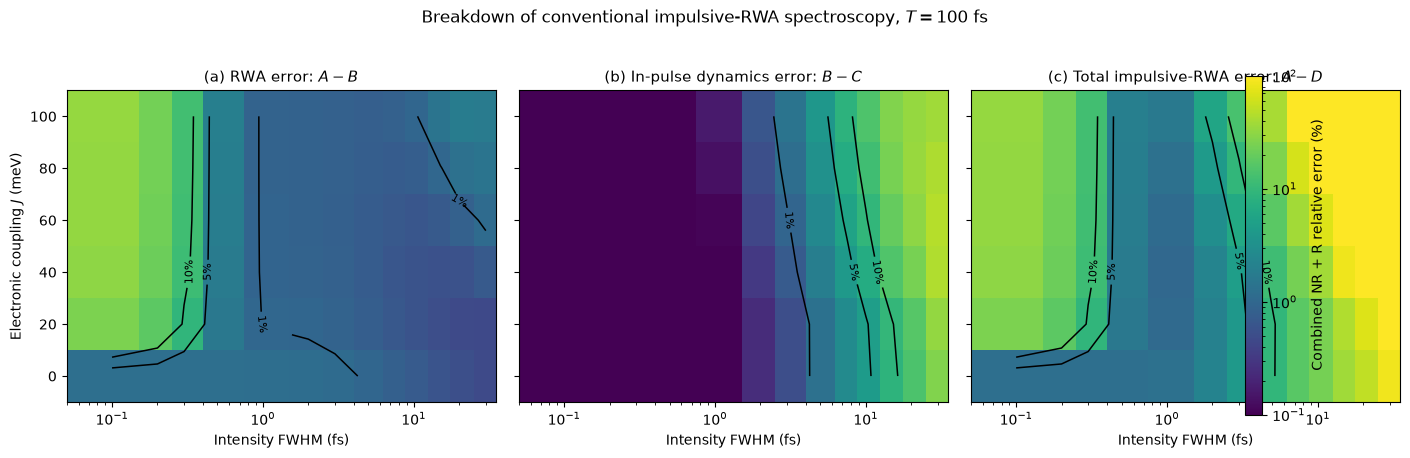

In [57]:
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Three-panel approximation-regime figure
# ------------------------------------------------------------

J_mesh_common, fwhm_mesh_common = np.meshgrid(
    1000.0 * J_scan_common,
    fwhm_scan_common,
    indexing="ij",
)

maps = [
    100.0 * AB_map,
    100.0 * BC_map_common,
    100.0 * AD_map,
]

titles = [
    r"(a) RWA error: $A-B$",
    r"(b) In-pulse dynamics error: $B-C$",
    r"(c) Total impulsive-RWA error: $A-D$",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14.2, 4.4),
    sharex=True,
    sharey=True,
)

norm = LogNorm(
    vmin=0.1,
    vmax=100.0,
)

for ax, data, title in zip(
    axes,
    maps,
    titles,
):

    pcm = ax.pcolormesh(
        fwhm_mesh_common,
        J_mesh_common,
        data,
        shading="auto",
        norm=norm,
    )

    # Only draw contour levels that actually exist
    levels = [
        level
        for level in [1.0, 5.0, 10.0]
        if np.min(data) <= level <= np.max(data)
    ]

    if levels:
        cs = ax.contour(
            fwhm_mesh_common,
            J_mesh_common,
            data,
            levels=levels,
            colors="black",
            linewidths=1.1,
        )

        ax.clabel(
            cs,
            fmt=lambda x: f"{x:.0f}%",
            fontsize=8,
        )

    ax.set_xscale("log")

    ax.set_xlabel(
        "Intensity FWHM (fs)"
    )

    ax.set_title(
        title,
        fontsize=11,
    )

axes[0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.025,
)

cbar.set_label(
    "Combined NR + R relative error (%)"
)

fig.suptitle(
    r"Breakdown of conventional impulsive-RWA spectroscopy, $T=100$ fs",
    y=1.03,
)

fig.tight_layout()

plt.show()

In [58]:
# ------------------------------------------------------------
# Representative spectra from the three pulse regimes
# ------------------------------------------------------------

J_rep = 0.040  # eV

representative_fwhm = {
    "RWA-sensitive": 0.10,
    "Safe": 1.00,
    "Finite-pulse": 20.0,
}

representative_results = {}

for label, fwhm_i in representative_fwhm.items():

    system_i, _ = build_system_for_J(
        J_rep
    )

    sigma_i = (
        fwhm_i
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    spectra_i = {}

    for pathway, omega1_i in [
        ("NR", omega1_grid),
        ("R", omega1_grid_R),
    ]:

        spectra_i[("A", pathway)] = (
            pulsus.finite_pulse_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=100.0,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra_i[("D", pathway)] = (
            pulsus.impulsive_rwa_spectrum(
                system=system_i,
                omega1=omega1_i,
                omega3=omega3_grid,
                T=100.0,
                eta=eta,
                pathway=pathway,
            )
        )

    representative_results[label] = {
        "fwhm_fs": fwhm_i,
        "spectra": spectra_i,
    }

    eps_AD_i = combined_relative_error(
        spectra_i[("D", "NR")],
        spectra_i[("A", "NR")],
        spectra_i[("D", "R")],
        spectra_i[("A", "R")],
    )

    print(
        f"{label:15s}  "
        f"FWHM = {fwhm_i:5.2f} fs   "
        f"A-D = {100*eps_AD_i:8.3f}%"
    )

RWA-sensitive    FWHM =  0.10 fs   A-D =   30.773%
Safe             FWHM =  1.00 fs   A-D =    1.018%
Finite-pulse     FWHM = 20.00 fs   A-D =  157.626%


In [59]:
# ------------------------------------------------------------
# Branch-resolved A-D errors for representative regimes
# ------------------------------------------------------------

print(
    "Regime             FWHM      NR A-D       R A-D"
)
print(
    "------------------------------------------------"
)

for label, result in representative_results.items():

    spectra_i = result["spectra"]

    err_NR = relative_error(
        spectra_i[("D", "NR")],
        spectra_i[("A", "NR")],
    )

    err_R = relative_error(
        spectra_i[("D", "R")],
        spectra_i[("A", "R")],
    )

    print(
        f"{label:16s} "
        f"{result['fwhm_fs']:5.2f} fs   "
        f"{100*err_NR:8.3f}%   "
        f"{100*err_R:8.3f}%"
    )

Regime             FWHM      NR A-D       R A-D
------------------------------------------------
RWA-sensitive     0.10 fs     42.200%      0.990%
Safe              1.00 fs      1.011%      1.025%
Finite-pulse     20.00 fs    161.254%    153.981%


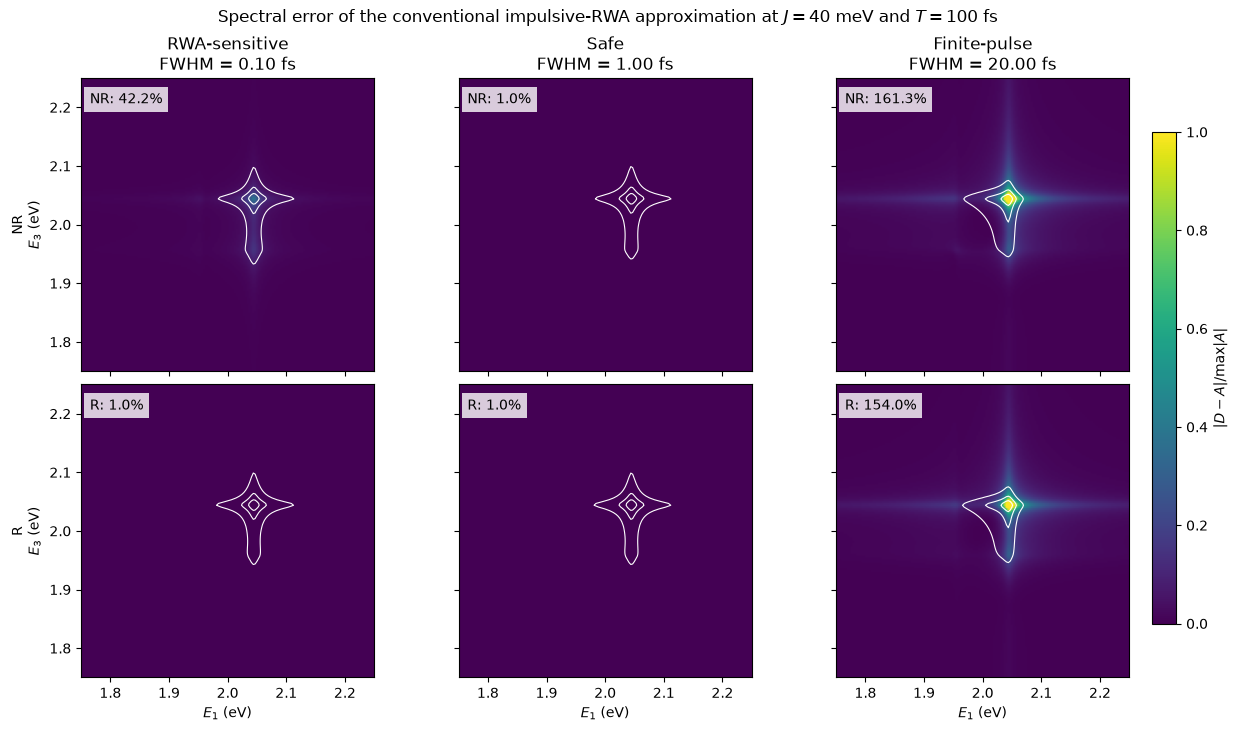

In [60]:
# ------------------------------------------------------------
# Representative spectral-error maps
#
# Color:   |D - A| / max(|A|)
# Contour: |A| / max(|A|)
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12.5, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

regime_order = [
    "RWA-sensitive",
    "Safe",
    "Finite-pulse",
]

pathway_order = [
    "NR",
    "R",
]

# Same normalized color range for all six panels
vmin = 0.0
vmax = 1.0

for row, pathway in enumerate(pathway_order):

    for col, label in enumerate(regime_order):

        ax = axes[row, col]

        result = representative_results[label]
        spectra_i = result["spectra"]

        A_i = spectra_i[("A", pathway)]
        D_i = spectra_i[("D", pathway)]

        scale = np.max(
            np.abs(A_i)
        )

        A_norm = (
            np.abs(A_i)
            / scale
        )

        diff_norm = (
            np.abs(D_i - A_i)
            / scale
        )

        im = ax.imshow(
            diff_norm,
            origin="lower",
            extent=[
                E1_grid[0],
                E1_grid[-1],
                E3_grid[0],
                E3_grid[-1],
            ],
            aspect="equal",
            vmin=vmin,
            vmax=vmax,
        )

        # Model-A spectral structure
        ax.contour(
            E1_grid,
            E3_grid,
            A_norm,
            levels=[
                0.10,
                0.30,
                0.60,
            ],
            colors="white",
            linewidths=0.8,
        )

        err = relative_error(
            D_i,
            A_i,
        )

        if row == 0:
            ax.set_title(
                f"{label}\n"
                f"FWHM = {result['fwhm_fs']:.2f} fs"
            )

        ax.text(
            0.03,
            0.95,
            f"{pathway}: {100*err:.1f}%",
            transform=ax.transAxes,
            ha="left",
            va="top",
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )

        if row == 1:
            ax.set_xlabel(
                r"$E_1$ (eV)"
            )

        if col == 0:
            ax.set_ylabel(
                rf"{pathway}" + "\n" + r"$E_3$ (eV)"
            )


cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.82,
    pad=0.02,
)

cbar.set_label(
    r"$|D-A|/\max|A|$"
)

fig.suptitle(
    r"Spectral error of the conventional impulsive-RWA approximation "
    r"at $J=40$ meV and $T=100$ fs",
)

plt.show()

## 6. Refinement of the impulsive-RWA safe regime

The coarse regime scan suggests a minimum total \(A-D\) error near a
pulse duration of approximately \(1\) fs. Because the original pulse
grid is sparse in this region, the minimum is refined before assigning
quantitative accuracy thresholds.

In [61]:
# ------------------------------------------------------------
# Fine scan of the impulsive-RWA safe valley
# ------------------------------------------------------------

fwhm_safe_scan = np.arange(
    0.40,
    2.01,
    0.10,
)

AD_safe_map = np.empty(
    (
        len(J_scan_common),
        len(fwhm_safe_scan),
    )
)

AB_safe_map = np.empty_like(
    AD_safe_map
)

BC_safe_map = np.empty_like(
    AD_safe_map
)

for i, J_i in enumerate(J_scan_common):

    for j, fwhm_i in enumerate(fwhm_safe_scan):

        result = evaluate_all_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=100.0,
        )

        AB_safe_map[i, j] = result["AB"]
        BC_safe_map[i, j] = result["BC"]
        AD_safe_map[i, j] = result["AD"]

    print(
        f"Finished J = {1000*J_i:6.1f} meV"
    )


print()
print("Refined safe-region minima")
print("---------------------------")

for i, J_i in enumerate(J_scan_common):

    j_best = np.argmin(
        AD_safe_map[i, :]
    )

    print(
        f"J = {1000*J_i:5.1f} meV   "
        f"best FWHM = {fwhm_safe_scan[j_best]:4.2f} fs   "
        f"AD = {100*AD_safe_map[i, j_best]:7.3f}%   "
        f"AB = {100*AB_safe_map[i, j_best]:7.3f}%   "
        f"BC = {100*BC_safe_map[i, j_best]:7.3f}%"
    )


i_best, j_best = np.unravel_index(
    np.argmin(AD_safe_map),
    AD_safe_map.shape,
)

print()
print("Global refined minimum")
print("----------------------")

print(
    f"J = {1000*J_scan_common[i_best]:.1f} meV"
)

print(
    f"FWHM = {fwhm_safe_scan[j_best]:.2f} fs"
)

print(
    f"A-D = {100*AD_safe_map[i_best, j_best]:.4f}%"
)

Finished J =    0.0 meV
Finished J =   20.0 meV
Finished J =   40.0 meV
Finished J =   60.0 meV
Finished J =   80.0 meV
Finished J =  100.0 meV

Refined safe-region minima
---------------------------
J =   0.0 meV   best FWHM = 0.40 fs   AD =   1.204%   AB =   1.200%   BC =   0.010%
J =  20.0 meV   best FWHM = 0.70 fs   AD =   1.009%   AB =   0.993%   BC =   0.029%
J =  40.0 meV   best FWHM = 0.70 fs   AD =   0.940%   AB =   0.928%   BC =   0.039%
J =  60.0 meV   best FWHM = 0.70 fs   AD =   0.937%   AB =   0.908%   BC =   0.052%
J =  80.0 meV   best FWHM = 0.70 fs   AD =   0.984%   AB =   0.897%   BC =   0.065%
J = 100.0 meV   best FWHM = 0.70 fs   AD =   1.088%   AB =   0.891%   BC =   0.079%

Global refined minimum
----------------------
J = 60.0 meV
FWHM = 0.70 fs
A-D = 0.9375%


In [62]:
# ------------------------------------------------------------
# Fine localization of the safe-valley minimum at J = 60 meV
# ------------------------------------------------------------

J_min_test = 0.060  # eV

fwhm_min_scan = np.arange(
    0.50,
    0.91,
    0.025,
)

min_scan_results = []

for fwhm_i in fwhm_min_scan:

    result = evaluate_all_for_J_and_pulse(
        J_eV=J_min_test,
        intensity_fwhm_fs=fwhm_i,
        T_fs=100.0,
    )

    min_scan_results.append(result)

    print(
        f"FWHM = {fwhm_i:5.3f} fs   "
        f"AB = {100*result['AB']:7.4f}%   "
        f"BC = {100*result['BC']:7.4f}%   "
        f"CD = {100*result['CD']:7.4f}%   "
        f"AD = {100*result['AD']:7.4f}%"
    )


AD_min_vals = np.array([
    r["AD"]
    for r in min_scan_results
])

i_best = np.argmin(
    AD_min_vals
)

best_result = min_scan_results[i_best]

print()
print("Best point at J = 60 meV")
print("------------------------")
print(
    f"FWHM = {best_result['fwhm_fs']:.3f} fs"
)
print(
    f"A-D = {100*best_result['AD']:.5f}%"
)

FWHM = 0.500 fs   AB =  1.8158%   BC =  0.0265%   CD =  0.1838%   AD =  1.8076%
FWHM = 0.525 fs   AB =  1.4664%   BC =  0.0293%   CD =  0.2026%   AD =  1.4595%
FWHM = 0.550 fs   AB =  1.2338%   BC =  0.0321%   CD =  0.2223%   AD =  1.2294%
FWHM = 0.575 fs   AB =  1.0887%   BC =  0.0351%   CD =  0.2430%   AD =  1.0881%
FWHM = 0.600 fs   AB =  1.0036%   BC =  0.0382%   CD =  0.2645%   AD =  1.0078%
FWHM = 0.625 fs   AB =  0.9558%   BC =  0.0415%   CD =  0.2870%   AD =  0.9656%
FWHM = 0.650 fs   AB =  0.9297%   BC =  0.0448%   CD =  0.3104%   AD =  0.9456%
FWHM = 0.675 fs   AB =  0.9155%   BC =  0.0483%   CD =  0.3347%   AD =  0.9381%
FWHM = 0.700 fs   AB =  0.9076%   BC =  0.0520%   CD =  0.3599%   AD =  0.9375%
FWHM = 0.725 fs   AB =  0.9030%   BC =  0.0558%   CD =  0.3860%   AD =  0.9410%
FWHM = 0.750 fs   AB =  0.9003%   BC =  0.0597%   CD =  0.4130%   AD =  0.9472%
FWHM = 0.775 fs   AB =  0.8985%   BC =  0.0637%   CD =  0.4409%   AD =  0.9552%
FWHM = 0.800 fs   AB =  0.8973%   BC =  

In [63]:
# ------------------------------------------------------------
# Refine the sub-1% safe corridor
# ------------------------------------------------------------

J_safe_refine = np.array([
    0.040,
    0.060,
    0.080,
])

fwhm_safe_refine = np.arange(
    0.50,
    1.001,
    0.025,
)

AD_corridor = np.empty(
    (
        len(J_safe_refine),
        len(fwhm_safe_refine),
    )
)

for i, J_i in enumerate(J_safe_refine):

    for j, fwhm_i in enumerate(fwhm_safe_refine):

        result = evaluate_all_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=100.0,
        )

        AD_corridor[i, j] = result["AD"]

    print(
        f"Finished J = {1000*J_i:.1f} meV"
    )


print()
print("Sub-1% corridor")
print("----------------")

for i, J_i in enumerate(J_safe_refine):

    mask = (
        100.0 * AD_corridor[i, :]
        < 1.0
    )

    if np.any(mask):

        safe_fwhm = (
            fwhm_safe_refine[mask]
        )

        j_best = np.argmin(
            AD_corridor[i, :]
        )

        print(
            f"J = {1000*J_i:5.1f} meV   "
            f"window = "
            f"{safe_fwhm[0]:.3f} to "
            f"{safe_fwhm[-1]:.3f} fs   "
            f"best = "
            f"{fwhm_safe_refine[j_best]:.3f} fs   "
            f"min AD = "
            f"{100*AD_corridor[i, j_best]:.4f}%"
        )

    else:

        print(
            f"J = {1000*J_i:5.1f} meV   "
            f"no sub-1% window"
        )

Finished J = 40.0 meV
Finished J = 60.0 meV
Finished J = 80.0 meV

Sub-1% corridor
----------------
J =  40.0 meV   window = 0.625 to 0.950 fs   best = 0.700 fs   min AD = 0.9403%
J =  60.0 meV   window = 0.625 to 0.850 fs   best = 0.700 fs   min AD = 0.9375%
J =  80.0 meV   window = 0.625 to 0.725 fs   best = 0.675 fs   min AD = 0.9769%


### Sub-1% impulsive-RWA corridor

Refinement of the total \(A-D\) error reveals a narrow region in which
the conventional impulsive-RWA description is accurate to better than
\(1\%\).

For \(J=40\), \(60\), and \(80\) meV, the sub-\(1\%\) pulse-duration
windows are approximately

\[
0.625-0.950\ {\rm fs},
\qquad
0.625-0.850\ {\rm fs},
\qquad
0.625-0.725\ {\rm fs},
\]

respectively.

The minimum total error occurs near a pulse duration of
\(0.7\) fs throughout this coupling range, while the allowed window
narrows as the electronic coupling increases.

In [64]:
# ------------------------------------------------------------
# Approximate 5% and 10% A-D accuracy windows
# from the existing common grid
# ------------------------------------------------------------

def threshold_window(
    x,
    y,
    threshold,
):
    """
    Approximate the contiguous x interval where y < threshold.

    Crossings are interpolated linearly in log10(x),
    which is appropriate for the logarithmic pulse-duration axis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = y < threshold

    if not np.any(mask):
        return None

    indices = np.where(mask)[0]

    i_left = indices[0]
    i_right = indices[-1]

    # Left crossing
    if i_left == 0:
        x_left = x[0]
    else:
        x1, x2 = x[i_left - 1], x[i_left]
        y1, y2 = y[i_left - 1], y[i_left]

        lx1 = np.log10(x1)
        lx2 = np.log10(x2)

        fraction = (
            (threshold - y1)
            / (y2 - y1)
        )

        x_left = 10**(
            lx1
            + fraction * (lx2 - lx1)
        )

    # Right crossing
    if i_right == len(x) - 1:
        x_right = x[-1]
    else:
        x1, x2 = x[i_right], x[i_right + 1]
        y1, y2 = y[i_right], y[i_right + 1]

        lx1 = np.log10(x1)
        lx2 = np.log10(x2)

        fraction = (
            (threshold - y1)
            / (y2 - y1)
        )

        x_right = 10**(
            lx1
            + fraction * (lx2 - lx1)
        )

    return x_left, x_right


print(
    "Approximate total A-D accuracy windows"
)
print(
    "--------------------------------------"
)

for i, J_i in enumerate(J_scan_common):

    AD_percent_i = (
        100.0 * AD_map[i, :]
    )

    window_5 = threshold_window(
        fwhm_scan_common,
        AD_percent_i,
        5.0,
    )

    window_10 = threshold_window(
        fwhm_scan_common,
        AD_percent_i,
        10.0,
    )

    text_5 = (
        "none"
        if window_5 is None
        else
        f"{window_5[0]:.3f}-{window_5[1]:.3f} fs"
    )

    text_10 = (
        "none"
        if window_10 is None
        else
        f"{window_10[0]:.3f}-{window_10[1]:.3f} fs"
    )

    print(
        f"J = {1000*J_i:5.1f} meV   "
        f"<5%: {text_5:18s}   "
        f"<10%: {text_10}"
    )

Approximate total A-D accuracy windows
--------------------------------------
J =   0.0 meV   <5%: 0.100-3.261 fs       <10%: 0.100-5.155 fs
J =  20.0 meV   <5%: 0.398-3.304 fs       <10%: 0.289-5.174 fs
J =  40.0 meV   <5%: 0.420-3.084 fs       <10%: 0.321-4.439 fs
J =  60.0 meV   <5%: 0.426-2.550 fs       <10%: 0.331-3.557 fs
J =  80.0 meV   <5%: 0.428-2.139 fs       <10%: 0.335-3.062 fs
J = 100.0 meV   <5%: 0.431-1.740 fs       <10%: 0.338-2.498 fs


In [65]:
def evaluate_all_on_grid(
    J_eV,
    intensity_fwhm_fs,
    E_min_i,
    E_max_i,
    n_omega_i,
    T_fs=100.0,
):
    system_i, DeltaE_i = build_system_for_J(
        J_eV
    )

    sigma_i = (
        intensity_fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    E1_i = np.linspace(
        E_min_i,
        E_max_i,
        n_omega_i,
    )

    E3_i = np.linspace(
        E_min_i,
        E_max_i,
        n_omega_i,
    )

    omega1_NR_i = (
        E1_i / HBAR_EV_FS
    )

    omega1_R_i = (
        -E1_i / HBAR_EV_FS
    )

    omega3_i = (
        E3_i / HBAR_EV_FS
    )

    spectra = {}

    for pathway, omega1_i in [
        ("NR", omega1_NR_i),
        ("R", omega1_R_i),
    ]:

        spectra[("A", pathway)] = (
            pulsus.finite_pulse_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_i,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("B", pathway)] = (
            pulsus.finite_pulse_rwa_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_i,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("C", pathway)] = (
            pulsus.short_pulse_rwa_spectrum(
                system=system_i,
                pulse1=pulse_i,
                pulse2=pulse_i,
                pulse3=pulse_i,
                omega1=omega1_i,
                omega3=omega3_i,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

        spectra[("D", pathway)] = (
            pulsus.impulsive_rwa_spectrum(
                system=system_i,
                omega1=omega1_i,
                omega3=omega3_i,
                T=T_fs,
                eta=eta,
                pathway=pathway,
            )
        )

    def comb(approx, ref):
        return combined_relative_error(
            spectra[(approx, "NR")],
            spectra[(ref, "NR")],
            spectra[(approx, "R")],
            spectra[(ref, "R")],
        )

    return {
        "AB": comb("B", "A"),
        "BC": comb("C", "B"),
        "CD": comb("D", "C"),
        "AD": comb("D", "A"),
    }

In [66]:
# ------------------------------------------------------------
# Spectral-grid convergence at the safe-valley minimum
# ------------------------------------------------------------

for n_i in [
    81,
    161,
    321,
    641,
]:

    result = evaluate_all_on_grid(
        J_eV=0.060,
        intensity_fwhm_fs=0.700,
        E_min_i=1.75,
        E_max_i=2.25,
        n_omega_i=n_i,
        T_fs=100.0,
    )

    spacing_meV = (
        1000.0
        * (2.25 - 1.75)
        / (n_i - 1)
    )

    print(
        f"n = {n_i:3d}   "
        f"dE = {spacing_meV:7.4f} meV   "
        f"AB = {100*result['AB']:8.5f}%   "
        f"BC = {100*result['BC']:8.5f}%   "
        f"CD = {100*result['CD']:8.5f}%   "
        f"AD = {100*result['AD']:8.5f}%"
    )

n =  81   dE =  6.2500 meV   AB =  0.90933%   BC =  0.05200%   CD =  0.36096%   AD =  0.93954%
n = 161   dE =  3.1250 meV   AB =  0.90757%   BC =  0.05199%   CD =  0.35986%   AD =  0.93749%
n = 321   dE =  1.5625 meV   AB =  0.90625%   BC =  0.05197%   CD =  0.35918%   AD =  0.93604%
n = 641   dE =  0.7812 meV   AB =  0.90558%   BC =  0.05197%   CD =  0.35884%   AD =  0.93531%


In [67]:
# ------------------------------------------------------------
# Spectral-window convergence at fixed energy resolution
# ------------------------------------------------------------

dE_target = 0.0015625  # eV = 1.5625 meV

windows = [
    (1.80, 2.20),
    (1.75, 2.25),
    (1.70, 2.30),
    (1.60, 2.40),
    (1.50, 2.50),
]

for Emin_i, Emax_i in windows:

    n_i = int(
        round(
            (Emax_i - Emin_i)
            / dE_target
        )
    ) + 1

    result = evaluate_all_on_grid(
        J_eV=0.060,
        intensity_fwhm_fs=0.700,
        E_min_i=Emin_i,
        E_max_i=Emax_i,
        n_omega_i=n_i,
        T_fs=100.0,
    )

    print(
        f"{Emin_i:.2f}-{Emax_i:.2f} eV   "
        f"n = {n_i:3d}   "
        f"AB = {100*result['AB']:8.5f}%   "
        f"BC = {100*result['BC']:8.5f}%   "
        f"CD = {100*result['CD']:8.5f}%   "
        f"AD = {100*result['AD']:8.5f}%"
    )

1.80-2.20 eV   n = 257   AB =  0.81608%   BC =  0.05108%   CD =  0.31891%   AD =  0.84019%
1.75-2.25 eV   n = 321   AB =  0.90625%   BC =  0.05197%   CD =  0.35918%   AD =  0.93604%
1.70-2.30 eV   n = 385   AB =  0.98715%   BC =  0.05276%   CD =  0.40616%   AD =  1.02751%
1.60-2.40 eV   n = 513   AB =  1.12824%   BC =  0.05416%   CD =  0.51917%   AD =  1.20385%
1.50-2.50 eV   n = 641   AB =  1.24841%   BC =  0.05538%   CD =  0.65338%   AD =  1.37734%


In [68]:
# ------------------------------------------------------------
# Window sensitivity in all three representative regimes
# ------------------------------------------------------------

window_tests = [
    (1.80, 2.20),
    (1.75, 2.25),
    (1.70, 2.30),
    (1.60, 2.40),
    (1.50, 2.50),
]

regime_tests = [
    ("RWA-sensitive", 0.040, 0.10),
    ("Safe",          0.060, 0.70),
    ("Finite-pulse",  0.040, 20.0),
]

dE_target = 0.0015625  # eV

for label, J_i, fwhm_i in regime_tests:

    print()
    print(label)
    print("-" * len(label))

    for Emin_i, Emax_i in window_tests:

        n_i = int(
            round(
                (Emax_i - Emin_i)
                / dE_target
            )
        ) + 1

        result = evaluate_all_on_grid(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            E_min_i=Emin_i,
            E_max_i=Emax_i,
            n_omega_i=n_i,
            T_fs=100.0,
        )

        print(
            f"{Emin_i:.2f}-{Emax_i:.2f} eV   "
            f"AB = {100*result['AB']:8.3f}%   "
            f"BC = {100*result['BC']:8.3f}%   "
            f"CD = {100*result['CD']:8.3f}%   "
            f"AD = {100*result['AD']:8.3f}%"
        )


RWA-sensitive
-------------
1.80-2.20 eV   AB =   30.782%   BC =    0.001%   CD =    0.004%   AD =   30.781%
1.75-2.25 eV   AB =   30.774%   BC =    0.001%   CD =    0.005%   AD =   30.774%
1.70-2.30 eV   AB =   30.770%   BC =    0.001%   CD =    0.007%   AD =   30.769%
1.60-2.40 eV   AB =   30.766%   BC =    0.001%   CD =    0.009%   AD =   30.765%
1.50-2.50 eV   AB =   30.765%   BC =    0.001%   CD =    0.013%   AD =   30.765%

Safe
----
1.80-2.20 eV   AB =    0.816%   BC =    0.051%   CD =    0.319%   AD =    0.840%
1.75-2.25 eV   AB =    0.906%   BC =    0.052%   CD =    0.359%   AD =    0.936%
1.70-2.30 eV   AB =    0.987%   BC =    0.053%   CD =    0.406%   AD =    1.028%
1.60-2.40 eV   AB =    1.128%   BC =    0.054%   CD =    0.519%   AD =    1.204%
1.50-2.50 eV   AB =    1.248%   BC =    0.055%   CD =    0.653%   AD =    1.377%

Finite-pulse
------------
1.80-2.20 eV   AB =    0.571%   BC =   24.456%   CD =  163.277%   AD =  156.433%
1.75-2.25 eV   AB =    0.571%   BC =   24.

### Spectral-window robustness

The approximation errors are evaluated over a fixed
\(1.75-2.25\) eV spectral window on both frequency axes.

The strongly non-RWA and strongly finite-pulse regimes are insensitive
to reasonable changes of this window. The precise location of a
\(1\%\) accuracy threshold is more sensitive because off-resonant
spectral weight contributes to the global Frobenius norm.

Accordingly, quoted quantitative errors should always be understood
with respect to the stated spectral analysis window.

In [69]:
import time

# ------------------------------------------------------------
# Dense J x pulse-duration regime scan
# ------------------------------------------------------------

J_dense = np.linspace(
    0.0,
    0.100,
    51,
)

fwhm_dense = np.geomspace(
    0.10,
    30.0,
    101,
)

shape_dense = (
    len(J_dense),
    len(fwhm_dense),
)

AB_dense = np.empty(shape_dense)
BC_dense = np.empty(shape_dense)
CD_dense = np.empty(shape_dense)
AD_dense = np.empty(shape_dense)

chi_dyn_dense = np.empty(shape_dense)
chi_RWA_dense = np.empty(shape_dense)


t0 = time.perf_counter()

for i, J_i in enumerate(J_dense):

    for j, fwhm_i in enumerate(fwhm_dense):

        result = evaluate_all_for_J_and_pulse(
            J_eV=J_i,
            intensity_fwhm_fs=fwhm_i,
            T_fs=100.0,
        )

        AB_dense[i, j] = result["AB"]
        BC_dense[i, j] = result["BC"]
        CD_dense[i, j] = result["CD"]
        AD_dense[i, j] = result["AD"]

        chi_dyn_dense[i, j] = result["chi_dyn"]
        chi_RWA_dense[i, j] = result["chi_RWA"]

    if (
        i % 10 == 0
        or i == len(J_dense) - 1
    ):
        print(
            f"Finished {i+1:2d}/{len(J_dense)} J values "
            f"(J = {1000*J_i:6.1f} meV)"
        )


elapsed = time.perf_counter() - t0

print()
print("Dense scan complete.")
print("Shape:", AD_dense.shape)
print(
    f"Total physical points: "
    f"{AD_dense.size}"
)
print(
    f"Runtime: {elapsed:.2f} s"
)

print()
print(
    "AB range:",
    f"{100*np.min(AB_dense):.4f}% to "
    f"{100*np.max(AB_dense):.2f}%"
)

print(
    "BC range:",
    f"{100*np.min(BC_dense):.4f}% to "
    f"{100*np.max(BC_dense):.2f}%"
)

print(
    "AD range:",
    f"{100*np.min(AD_dense):.4f}% to "
    f"{100*np.max(AD_dense):.2f}%"
)


i_best, j_best = np.unravel_index(
    np.argmin(AD_dense),
    AD_dense.shape,
)

print()
print("Dense-grid minimum")
print("------------------")
print(
    f"J = {1000*J_dense[i_best]:.2f} meV"
)
print(
    f"FWHM = {fwhm_dense[j_best]:.4f} fs"
)
print(
    f"A-D = {100*AD_dense[i_best, j_best]:.5f}%"
)

Finished  1/51 J values (J =    0.0 meV)
Finished 11/51 J values (J =   20.0 meV)
Finished 21/51 J values (J =   40.0 meV)
Finished 31/51 J values (J =   60.0 meV)
Finished 41/51 J values (J =   80.0 meV)
Finished 51/51 J values (J =  100.0 meV)

Dense scan complete.
Shape: (51, 101)
Total physical points: 5151
Runtime: 513.40 s

AB range: 0.4445% to 33.37%
BC range: 0.0006% to 46.47%
AD range: 0.9341% to 4885.70%

Dense-grid minimum
------------------
J = 56.00 meV
FWHM = 0.6954 fs
A-D = 0.93407%


In [70]:
# ------------------------------------------------------------
# Save dense regime-scan checkpoint
# ------------------------------------------------------------

dense_scan_file = Path(
    "07_dense_regime_scan.npz"
)

np.savez_compressed(
    dense_scan_file,
    J_dense=J_dense,
    fwhm_dense=fwhm_dense,
    AB_dense=AB_dense,
    BC_dense=BC_dense,
    CD_dense=CD_dense,
    AD_dense=AD_dense,
    chi_dyn_dense=chi_dyn_dense,
    chi_RWA_dense=chi_RWA_dense,
)

print(
    "Saved:",
    dense_scan_file.resolve()
)

print(
    "Size:",
    f"{dense_scan_file.stat().st_size / 1024**2:.2f} MB"
)

Saved: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/notebooks/07_dense_regime_scan.npz
Size: 0.19 MB


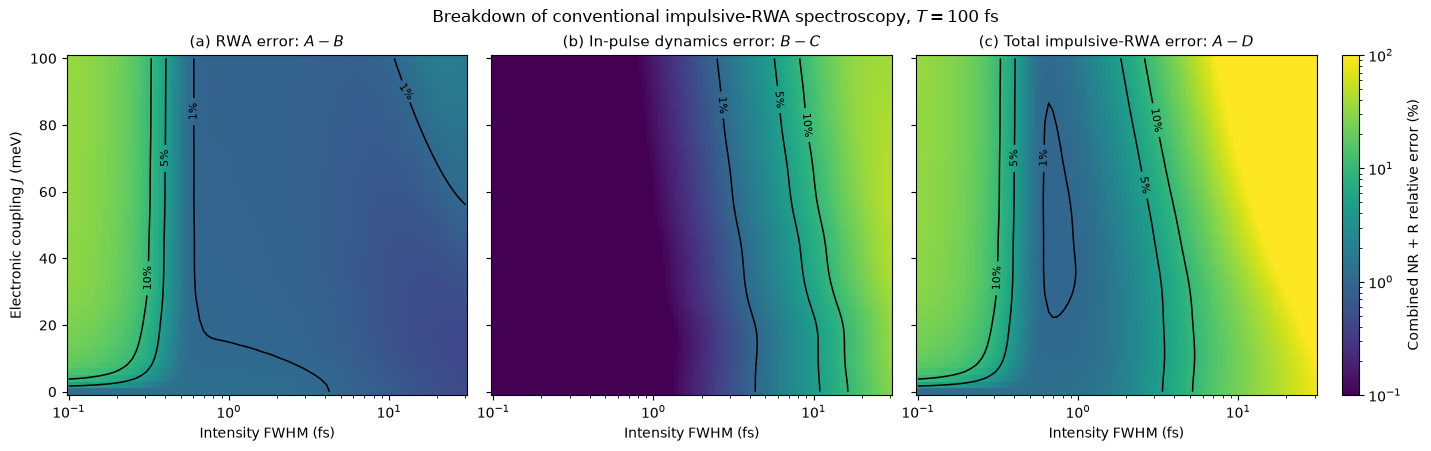

In [71]:
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Dense three-panel regime map
# ------------------------------------------------------------

J_mesh_dense, fwhm_mesh_dense = np.meshgrid(
    1000.0 * J_dense,
    fwhm_dense,
    indexing="ij",
)

maps_dense = [
    100.0 * AB_dense,
    100.0 * BC_dense,
    100.0 * AD_dense,
]

titles_dense = [
    r"(a) RWA error: $A-B$",
    r"(b) In-pulse dynamics error: $B-C$",
    r"(c) Total impulsive-RWA error: $A-D$",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14.2, 4.4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = LogNorm(
    vmin=0.1,
    vmax=100.0,
)

for ax, data, title in zip(
    axes,
    maps_dense,
    titles_dense,
):

    pcm = ax.pcolormesh(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        shading="auto",
        norm=norm,
    )

    cs = ax.contour(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        levels=[1.0, 5.0, 10.0],
        colors="black",
        linewidths=1.1,
    )

    ax.clabel(
        cs,
        fmt=lambda x: f"{x:.0f}%",
        fontsize=8,
    )

    ax.set_xscale("log")

    ax.set_xlabel(
        "Intensity FWHM (fs)"
    )

    ax.set_title(
        title,
        fontsize=11,
    )

axes[0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.025,
)

cbar.set_label(
    "Combined NR + R relative error (%)"
)

fig.suptitle(
    r"Breakdown of conventional impulsive-RWA spectroscopy, "
    r"$T=100$ fs",
)

plt.show()

In [72]:
# ------------------------------------------------------------
# Dense-grid 1%, 5%, and 10% accuracy boundaries
# ------------------------------------------------------------

thresholds = [
    1.0,
    5.0,
    10.0,
]

boundary_data = {
    threshold: []
    for threshold in thresholds
}

for i, J_i in enumerate(J_dense):

    AD_percent_i = (
        100.0 * AD_dense[i, :]
    )

    for threshold in thresholds:

        window = threshold_window(
            fwhm_dense,
            AD_percent_i,
            threshold,
        )

        if window is None:
            boundary_data[threshold].append(
                (np.nan, np.nan)
            )
        else:
            boundary_data[threshold].append(
                window
            )


# Convert to arrays
for threshold in thresholds:
    boundary_data[threshold] = np.array(
        boundary_data[threshold]
    )


# ------------------------------------------------------------
# Coupling range over which sub-1% accuracy exists
# ------------------------------------------------------------

one_percent = boundary_data[1.0]

valid_1pct = np.isfinite(
    one_percent[:, 0]
)

print("Dense-grid total A-D accuracy")
print("--------------------------------")
print()

if np.any(valid_1pct):

    J_valid = (
        1000.0
        * J_dense[valid_1pct]
    )

    print(
        "Sub-1% region exists for approximately:"
    )

    print(
        f"J = {J_valid[0]:.1f} to "
        f"{J_valid[-1]:.1f} meV"
    )

else:

    print("No sub-1% region found.")


print()
print(
    "Selected dense-grid accuracy windows"
)
print(
    "------------------------------------"
)

for J_target_meV in [
    0,
    20,
    40,
    60,
    80,
    100,
]:

    i = np.argmin(
        np.abs(
            1000.0 * J_dense
            - J_target_meV
        )
    )

    print(
        f"J = {1000*J_dense[i]:5.1f} meV"
    )

    for threshold in thresholds:

        lo, hi = boundary_data[
            threshold
        ][i]

        if np.isfinite(lo):

            print(
                f"    < {threshold:2.0f}% : "
                f"{lo:7.4f} to "
                f"{hi:7.4f} fs"
            )

        else:

            print(
                f"    < {threshold:2.0f}% : none"
            )

Dense-grid total A-D accuracy
--------------------------------

Sub-1% region exists for approximately:
J = 24.0 to 86.0 meV

Selected dense-grid accuracy windows
------------------------------------
J =   0.0 meV
    <  1% : none
    <  5% :  0.1000 to  3.3641 fs
    < 10% :  0.1000 to  5.1866 fs
J =  20.0 meV
    <  1% : none
    <  5% :  0.3728 to  3.4219 fs
    < 10% :  0.2897 to  5.2160 fs
J =  40.0 meV
    <  1% :  0.6087 to  0.9575 fs
    <  5% :  0.3929 to  3.1289 fs
    < 10% :  0.3154 to  4.5883 fs
J =  60.0 meV
    <  1% :  0.6071 to  0.8718 fs
    <  5% :  0.3989 to  2.6438 fs
    < 10% :  0.3223 to  3.7753 fs
J =  80.0 meV
    <  1% :  0.6199 to  0.7321 fs
    <  5% :  0.4021 to  2.1990 fs
    < 10% :  0.3256 to  3.1055 fs
J = 100.0 meV
    <  1% : none
    <  5% :  0.4045 to  1.8489 fs
    < 10% :  0.3278 to  2.6011 fs


### Dense regime boundaries

The dense \(J\)-pulse-duration scan confirms a narrow accuracy
corridor for the conventional impulsive-RWA approximation.

Within the fixed \(1.75-2.25\) eV analysis window, a total
\(A-D\) error below \(1\%\) occurs only over approximately

\[
24 \lesssim J \lesssim 86\ {\rm meV}.
\]

The sub-\(1\%\) pulse-duration interval narrows substantially with
increasing electronic coupling. Representative windows are

\[
0.609-0.958\ {\rm fs}
\quad (J=40\ {\rm meV}),
\]

\[
0.607-0.872\ {\rm fs}
\quad (J=60\ {\rm meV}),
\]

and

\[
0.620-0.732\ {\rm fs}
\quad (J=80\ {\rm meV}).
\]

The lower boundary varies only weakly with coupling, consistent with
the ultrashort-pulse side being controlled primarily by RWA breakdown.
The upper boundary moves progressively toward shorter pulses as the
electronic coupling increases, consistent with increasing importance
of finite-pulse molecular dynamics.

The minimum total error on the dense grid is

\[
\epsilon_{AD}=0.934\%
\]

at approximately

\[
J=56\ {\rm meV},
\qquad
{\rm FWHM}=0.695\ {\rm fs}.
\]

In [73]:
# ------------------------------------------------------------
# Dimensionless diagnostics along A-D accuracy boundaries
# ------------------------------------------------------------

def sigma_from_fwhm(fwhm_fs):
    return (
        fwhm_fs
        / (2.0 * np.sqrt(np.log(2.0)))
    )


def chi_rwa_from_fwhm(fwhm_fs):
    sigma_i = sigma_from_fwhm(
        fwhm_fs
    )

    return (
        2.0
        * sigma_i
        * omega_L
    )


def chi_dyn_from_J_fwhm(
    J_eV,
    fwhm_fs,
):
    sigma_i = sigma_from_fwhm(
        fwhm_fs
    )

    DeltaE_i = np.sqrt(
        detuning**2
        + 4.0 * J_eV**2
    )

    return (
        sigma_i
        * DeltaE_i
        / HBAR_EV_FS
    )


boundary_diagnostics = {}

for threshold in thresholds:

    bounds = boundary_data[
        threshold
    ]

    J_vals = []
    fwhm_left_vals = []
    fwhm_right_vals = []
    chi_rwa_left_vals = []
    chi_dyn_right_vals = []

    for i, J_i in enumerate(J_dense):

        left_i, right_i = bounds[i]

        if not np.isfinite(left_i):
            continue

        # Exclude left boundaries clipped by
        # the lower edge of the scan.
        left_is_resolved = (
            left_i
            > fwhm_dense[0] * 1.0001
        )

        J_vals.append(
            1000.0 * J_i
        )

        fwhm_left_vals.append(
            left_i
        )

        fwhm_right_vals.append(
            right_i
        )

        if left_is_resolved:
            chi_rwa_left_vals.append(
                chi_rwa_from_fwhm(
                    left_i
                )
            )
        else:
            chi_rwa_left_vals.append(
                np.nan
            )

        chi_dyn_right_vals.append(
            chi_dyn_from_J_fwhm(
                J_i,
                right_i,
            )
        )

    boundary_diagnostics[
        threshold
    ] = {
        "J_meV": np.array(J_vals),
        "fwhm_left": np.array(
            fwhm_left_vals
        ),
        "fwhm_right": np.array(
            fwhm_right_vals
        ),
        "chi_RWA_left": np.array(
            chi_rwa_left_vals
        ),
        "chi_dyn_right": np.array(
            chi_dyn_right_vals
        ),
    }


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

for threshold in thresholds:

    data = boundary_diagnostics[
        threshold
    ]

    chi_rwa_i = data[
        "chi_RWA_left"
    ]

    chi_dyn_i = data[
        "chi_dyn_right"
    ]

    chi_rwa_i = chi_rwa_i[
        np.isfinite(chi_rwa_i)
    ]

    chi_dyn_i = chi_dyn_i[
        np.isfinite(chi_dyn_i)
    ]

    print()
    print(
        f"{threshold:.0f}% A-D contour"
    )
    print(
        "----------------------"
    )

    print(
        "Left boundary:"
    )

    print(
        f"  chi_RWA mean = "
        f"{np.mean(chi_rwa_i):.3f}"
    )

    print(
        f"  chi_RWA std  = "
        f"{np.std(chi_rwa_i):.3f}"
    )

    print(
        f"  chi_RWA range = "
        f"{np.min(chi_rwa_i):.3f} to "
        f"{np.max(chi_rwa_i):.3f}"
    )

    print(
        "Right boundary:"
    )

    print(
        f"  chi_dyn mean = "
        f"{np.mean(chi_dyn_i):.3f}"
    )

    print(
        f"  chi_dyn std  = "
        f"{np.std(chi_dyn_i):.3f}"
    )

    print(
        f"  chi_dyn range = "
        f"{np.min(chi_dyn_i):.3f} to "
        f"{np.max(chi_dyn_i):.3f}"
    )


1% A-D contour
----------------------
Left boundary:
  chi_RWA mean = 2.250
  chi_RWA std  = 0.047
  chi_RWA range = 2.213 to 2.394
Right boundary:
  chi_dyn mean = 0.090
  chi_dyn std  = 0.019
  chi_dyn range = 0.045 to 0.110

5% A-D contour
----------------------
Left boundary:
  chi_RWA mean = 1.392
  chi_RWA std  = 0.159
  chi_RWA range = 0.521 to 1.476
Right boundary:
  chi_dyn mean = 0.260
  chi_dyn std  = 0.074
  chi_dyn range = 0.123 to 0.344

10% A-D contour
----------------------
Left boundary:
  chi_RWA mean = 1.115
  chi_RWA std  = 0.139
  chi_RWA range = 0.429 to 1.196
Right boundary:
  chi_dyn mean = 0.376
  chi_dyn std  = 0.097
  chi_dyn range = 0.189 to 0.484


In [74]:
# ------------------------------------------------------------
# Dimensionless diagnostics for the individual approximation steps
# ------------------------------------------------------------

def get_boundary_array(
    error_map,
    threshold,
):
    bounds = []

    for i in range(len(J_dense)):

        error_percent = (
            100.0 * error_map[i, :]
        )

        window = threshold_window(
            fwhm_dense,
            error_percent,
            threshold,
        )

        if window is None:
            bounds.append(
                (np.nan, np.nan)
            )
        else:
            bounds.append(
                window
            )

    return np.array(bounds)


for threshold in [
    1.0,
    5.0,
    10.0,
]:

    AB_bounds = get_boundary_array(
        AB_dense,
        threshold,
    )

    BC_bounds = get_boundary_array(
        BC_dense,
        threshold,
    )

    CD_bounds = get_boundary_array(
        CD_dense,
        threshold,
    )

    # --------------------------------
    # A-B: short-pulse RWA boundary
    # --------------------------------

    chi_rwa_AB = []

    for i, J_i in enumerate(J_dense):

        left_i = AB_bounds[i, 0]

        if (
            np.isfinite(left_i)
            and left_i
            > fwhm_dense[0] * 1.0001
        ):
            chi_rwa_AB.append(
                chi_rwa_from_fwhm(
                    left_i
                )
            )

    chi_rwa_AB = np.array(
        chi_rwa_AB
    )

    # --------------------------------
    # B-C: long-pulse dynamics boundary
    # --------------------------------

    chi_dyn_BC = []

    for i, J_i in enumerate(J_dense):

        right_i = BC_bounds[i, 1]

        if np.isfinite(right_i):

            chi_dyn_BC.append(
                chi_dyn_from_J_fwhm(
                    J_i,
                    right_i,
                )
            )

    chi_dyn_BC = np.array(
        chi_dyn_BC
    )

    # --------------------------------
    # C-D: bandwidth boundary
    # --------------------------------

    fwhm_CD = CD_bounds[:, 1]

    fwhm_CD = fwhm_CD[
        np.isfinite(fwhm_CD)
    ]

    print()
    print(
        f"{threshold:.0f}% threshold"
    )
    print(
        "----------------"
    )

    print(
        "A-B RWA boundary:"
    )

    print(
        f"  chi_RWA mean  = "
        f"{np.mean(chi_rwa_AB):.3f}"
    )

    print(
        f"  chi_RWA std   = "
        f"{np.std(chi_rwa_AB):.3f}"
    )

    print(
        f"  chi_RWA range = "
        f"{np.min(chi_rwa_AB):.3f} to "
        f"{np.max(chi_rwa_AB):.3f}"
    )

    print(
        "B-C dynamics boundary:"
    )

    print(
        f"  chi_dyn mean  = "
        f"{np.mean(chi_dyn_BC):.3f}"
    )

    print(
        f"  chi_dyn std   = "
        f"{np.std(chi_dyn_BC):.3f}"
    )

    print(
        f"  chi_dyn range = "
        f"{np.min(chi_dyn_BC):.3f} to "
        f"{np.max(chi_dyn_BC):.3f}"
    )

    print(
        "C-D bandwidth boundary:"
    )

    print(
        f"  FWHM mean     = "
        f"{np.mean(fwhm_CD):.3f} fs"
    )

    print(
        f"  FWHM std      = "
        f"{np.std(fwhm_CD):.3f} fs"
    )

    print(
        f"  FWHM range    = "
        f"{np.min(fwhm_CD):.3f} to "
        f"{np.max(fwhm_CD):.3f} fs"
    )


1% threshold
----------------
A-B RWA boundary:
  chi_RWA mean  = 3.525
  chi_RWA std   = 3.337
  chi_RWA range = 2.203 to 15.493
B-C dynamics boundary:
  chi_dyn mean  = 0.319
  chi_dyn std   = 0.096
  chi_dyn range = 0.158 to 0.465
C-D bandwidth boundary:
  FWHM mean     = 1.222 fs
  FWHM std      = 0.217 fs
  FWHM range    = 0.831 to 1.475 fs

5% threshold
----------------
A-B RWA boundary:
  chi_RWA mean  = 1.393
  chi_RWA std   = 0.158
  chi_RWA range = 0.521 to 1.476
B-C dynamics boundary:
  chi_dyn mean  = 0.740
  chi_dyn std   = 0.206
  chi_dyn range = 0.399 to 1.057
C-D bandwidth boundary:
  FWHM mean     = 2.808 fs
  FWHM std      = 0.558 fs
  FWHM range    = 1.847 to 3.493 fs

10% threshold
----------------
A-B RWA boundary:
  chi_RWA mean  = 1.115
  chi_RWA std   = 0.139
  chi_RWA range = 0.429 to 1.196
B-C dynamics boundary:
  chi_dyn mean  = 1.074
  chi_dyn std   = 0.291
  chi_dyn range = 0.597 to 1.523
C-D bandwidth boundary:
  FWHM mean     = 4.114 fs
  FWHM std      =

### Dimensionless interpretation of the regime boundaries

The dense regime scan confirms that the dimensionless dynamical
parameter

\[
\chi_{\rm dyn}
=
\sigma\Delta E_{\rm ex}/\hbar
\]

provides a useful indicator of the breakdown of the short-pulse
approximation. Along the \(B-C\) boundaries, the mean values are
approximately

\[
\chi_{\rm dyn}=0.32,\ 0.74,\ 1.07
\]

for \(1\%\), \(5\%\), and \(10\%\) errors, respectively. In particular,
an order-one value of \(\chi_{\rm dyn}\) corresponds to substantial
in-pulse dynamical error.

The scatter along each contour shows, however, that
\(\chi_{\rm dyn}\) is not a universal predictor of a specified
percentage error.

The simple optical parameter

\[
\chi_{\rm RWA}=2\sigma\omega_L
\]

shows substantially stronger system dependence. This is consistent
with the molecular-sequence analysis, which showed that electronic
coupling activates a large nonrephasing beyond-RWA contribution.
Consequently, RWA accuracy cannot be determined from the optical pulse
timescale alone.

The \(C-D\) bandwidth error is also not determined solely by pulse
duration, since the scalar pulse envelope filters a molecular spectrum
whose resonances and pathway weights depend on the Hamiltonian.

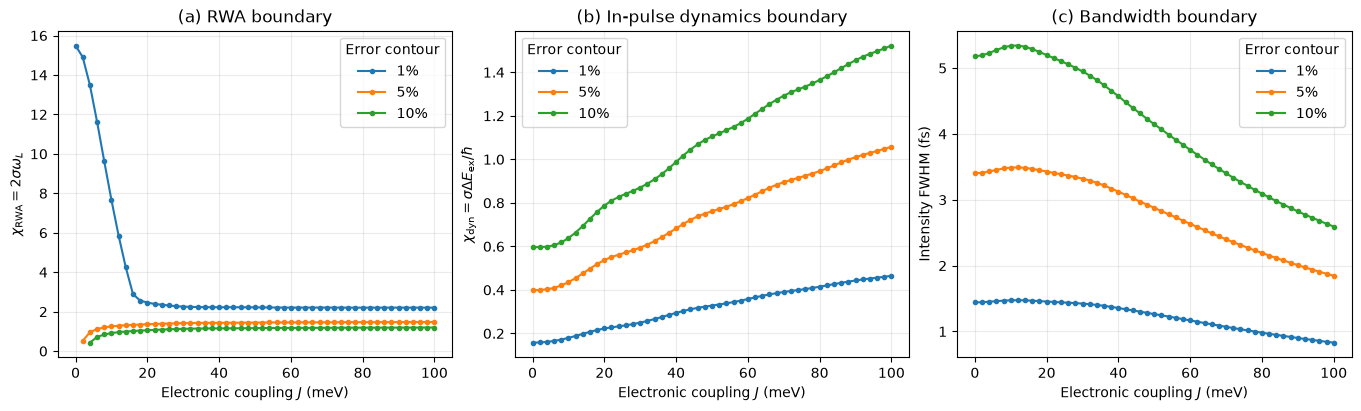

In [75]:
# ------------------------------------------------------------
# Boundary diagnostics versus electronic coupling
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.0),
    constrained_layout=True,
)

for threshold in [1.0, 5.0, 10.0]:

    AB_bounds = get_boundary_array(
        AB_dense,
        threshold,
    )

    BC_bounds = get_boundary_array(
        BC_dense,
        threshold,
    )

    CD_bounds = get_boundary_array(
        CD_dense,
        threshold,
    )

    # A-B
    J_AB = []
    chi_AB = []

    for i, J_i in enumerate(J_dense):

        left_i = AB_bounds[i, 0]

        if (
            np.isfinite(left_i)
            and left_i
            > fwhm_dense[0] * 1.0001
        ):
            J_AB.append(
                1000.0 * J_i
            )

            chi_AB.append(
                chi_rwa_from_fwhm(
                    left_i
                )
            )

    axes[0].plot(
        J_AB,
        chi_AB,
        marker="o",
        markersize=3,
        label=f"{threshold:.0f}%",
    )

    # B-C
    J_BC = []
    chi_BC = []

    for i, J_i in enumerate(J_dense):

        right_i = BC_bounds[i, 1]

        if np.isfinite(right_i):

            J_BC.append(
                1000.0 * J_i
            )

            chi_BC.append(
                chi_dyn_from_J_fwhm(
                    J_i,
                    right_i,
                )
            )

    axes[1].plot(
        J_BC,
        chi_BC,
        marker="o",
        markersize=3,
        label=f"{threshold:.0f}%",
    )

    # C-D
    mask_CD = np.isfinite(
        CD_bounds[:, 1]
    )

    axes[2].plot(
        1000.0 * J_dense[mask_CD],
        CD_bounds[mask_CD, 1],
        marker="o",
        markersize=3,
        label=f"{threshold:.0f}%",
    )


axes[0].set_title(
    r"(a) RWA boundary"
)
axes[0].set_ylabel(
    r"$\chi_{\rm RWA}=2\sigma\omega_L$"
)

axes[1].set_title(
    r"(b) In-pulse dynamics boundary"
)
axes[1].set_ylabel(
    r"$\chi_{\rm dyn}=\sigma\Delta E_{\rm ex}/\hbar$"
)

axes[2].set_title(
    r"(c) Bandwidth boundary"
)
axes[2].set_ylabel(
    "Intensity FWHM (fs)"
)

for ax in axes:

    ax.set_xlabel(
        r"Electronic coupling $J$ (meV)"
    )

    ax.legend(
        title="Error contour"
    )

    ax.grid(
        alpha=0.25
    )

plt.show()

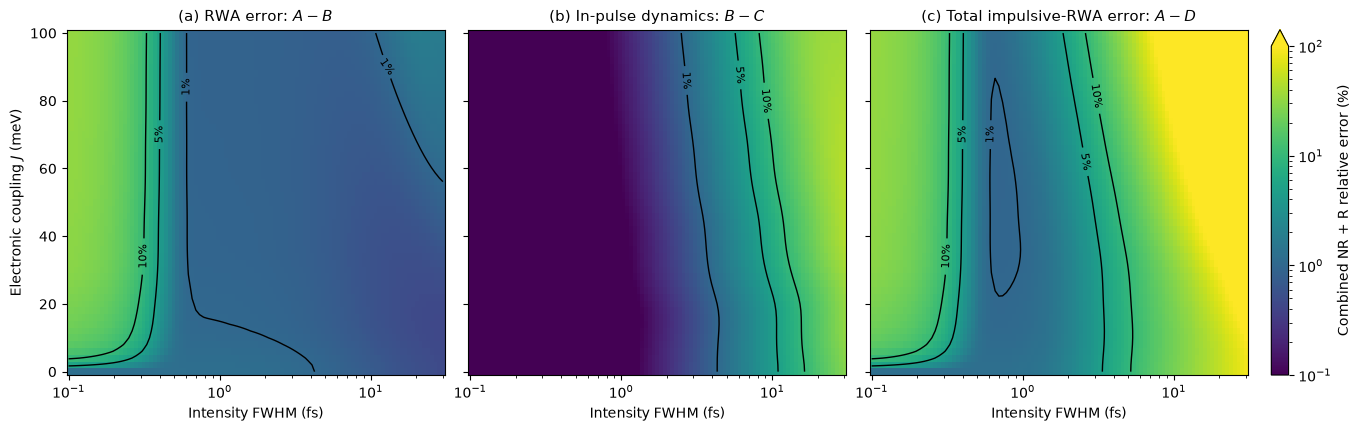

Saved:
../figures/07_physical_dimer_regimes/Figure04_regime_map.pdf
../figures/07_physical_dimer_regimes/Figure04_regime_map.png


In [76]:
# ------------------------------------------------------------
# Publication version: dense regime map
# ------------------------------------------------------------

from pathlib import Path
from matplotlib.colors import LogNorm

figdir = Path(
    "../figures/07_physical_dimer_regimes"
)

figdir.mkdir(
    parents=True,
    exist_ok=True,
)

J_mesh_dense, fwhm_mesh_dense = np.meshgrid(
    1000.0 * J_dense,
    fwhm_dense,
    indexing="ij",
)

maps_dense = [
    100.0 * AB_dense,
    100.0 * BC_dense,
    100.0 * AD_dense,
]

titles_dense = [
    r"(a) RWA error: $A-B$",
    r"(b) In-pulse dynamics: $B-C$",
    r"(c) Total impulsive-RWA error: $A-D$",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = LogNorm(
    vmin=0.1,
    vmax=100.0,
)

for ax, data, title in zip(
    axes,
    maps_dense,
    titles_dense,
):

    pcm = ax.pcolormesh(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        shading="auto",
        norm=norm,
    )

    cs = ax.contour(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        levels=[1.0, 5.0, 10.0],
        colors="black",
        linewidths=1.0,
    )

    ax.clabel(
        cs,
        fmt=lambda x: f"{x:.0f}%",
        fontsize=8,
    )

    ax.set_xscale("log")

    ax.set_xlabel(
        "Intensity FWHM (fs)"
    )

    ax.set_title(
        title,
        fontsize=11,
    )

axes[0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.025,
    extend="max",
)

cbar.set_label(
    "Combined NR + R relative error (%)"
)

pdf_file = (
    figdir
    / "Figure04_regime_map.pdf"
)

png_file = (
    figdir
    / "Figure04_regime_map.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

## Physical picture of the impulsive-RWA validity regime

The controlled approximation hierarchy reveals two distinct boundaries
of the conventional impulsive-RWA description.

At ultrashort pulse durations, the dominant failure is the rotating-wave
approximation. Molecular-sequence decomposition shows that electronic
coupling activates a large nonrephasing beyond-RWA contribution that is
absent from the conventional RWA pathway.

At longer pulse durations, finite-pulse effects become increasingly
important. Molecular evolution during the pulse is organized
qualitatively by

\[
\chi_{\rm dyn}
=
\sigma\Delta E_{\rm ex}/\hbar,
\]

with order-one values corresponding to substantial dynamical error.
However, the quantitative error retains dependence on the molecular
Hamiltonian and spectral structure.

The combination of the two mechanisms produces a finite accuracy
corridor in pulse duration. For the present dimer model and the fixed
\(1.75-2.25\) eV analysis window, the dense parameter scan gives a
minimum total impulsive-RWA error of

\[
\epsilon_{AD}=0.934\%
\]

near

\[
J=56\ {\rm meV},
\qquad
{\rm FWHM}=0.695\ {\rm fs}.
\]

A sub-\(1\%\) region exists approximately over

\[
24 \lesssim J \lesssim 86\ {\rm meV}.
\]

Thus the conventional impulsive-RWA treatment is accurate only within
a finite intermediate regime: pulses that are too short expose
counter-rotating molecular pathways, whereas pulses that are too long
resolve finite-pulse molecular dynamics and spectral filtering.

In [79]:
# ------------------------------------------------------------
# Publication representative regimes for Figure 5
# Fixed molecular system: J = 40 meV, T = 100 fs
# ------------------------------------------------------------

J_rep = 0.040
T_rep = 100.0

representative_fwhm = {
    "RWA-sensitive": 0.10,
    "Safe":          0.70,
    "Finite-pulse": 20.0,
}

system_rep, _ = build_system_for_J(
    J_rep
)

representative_results_pub = {}

for label, fwhm_i in representative_fwhm.items():

    sigma_i = (
        fwhm_i
        / (2.0 * np.sqrt(np.log(2.0)))
    )

    E0_i = (
        2.0
        / (
            np.sqrt(2.0 * np.pi)
            * sigma_i
        )
    )

    pulse_i = pulsus.GaussianPulse(
        omega_L=omega_L,
        sigma=sigma_i,
        E0=E0_i,
    )

    representative_results_pub[label] = {}

    for pathway, omega1_i in [
        ("NR", omega1_grid),
        ("R", omega1_grid_R),
    ]:

        A_i = pulsus.finite_pulse_spectrum(
            system=system_rep,
            pulse1=pulse_i,
            pulse2=pulse_i,
            pulse3=pulse_i,
            omega1=omega1_i,
            omega3=omega3_grid,
            T=T_rep,
            eta=eta,
            pathway=pathway,
        )

        D_i = pulsus.impulsive_rwa_spectrum(
            system=system_rep,
            omega1=omega1_i,
            omega3=omega3_grid,
            T=T_rep,
            eta=eta,
            pathway=pathway,
        )

        err_i = (
            np.linalg.norm(D_i - A_i)
            / np.linalg.norm(A_i)
        )

        representative_results_pub[label][pathway] = {
            "A": A_i,
            "D": D_i,
            "error": err_i,
        }


print(
    "Representative branch-resolved A-D errors"
)
print(
    "-----------------------------------------"
)

for label in representative_fwhm:

    print(
        f"{label:14s}  "
        f"FWHM = {representative_fwhm[label]:5.2f} fs  "
        f"NR = "
        f"{100*representative_results_pub[label]['NR']['error']:7.3f}%  "
        f"R = "
        f"{100*representative_results_pub[label]['R']['error']:7.3f}%"
    )

Representative branch-resolved A-D errors
-----------------------------------------
RWA-sensitive   FWHM =  0.10 fs  NR =  42.200%  R =   0.990%
Safe            FWHM =  0.70 fs  NR =   0.941%  R =   0.939%
Finite-pulse    FWHM = 20.00 fs  NR = 161.254%  R = 153.981%


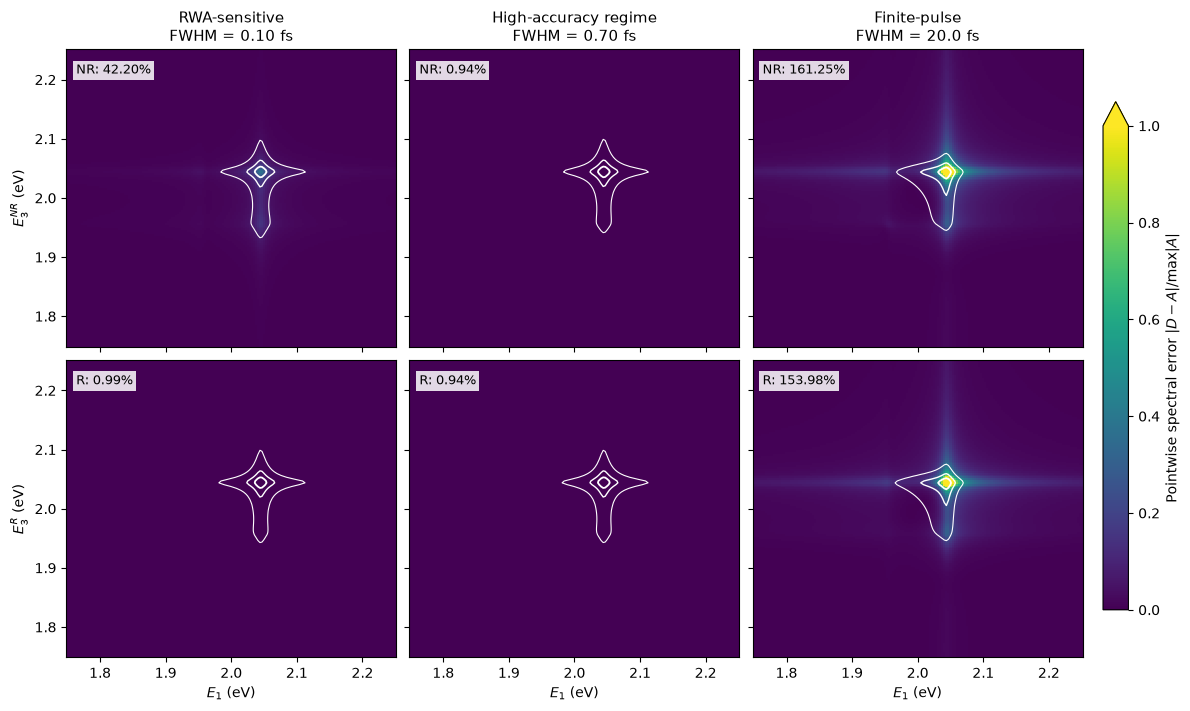

Saved:
../figures/07_physical_dimer_regimes/Figure05_representative_spectral_errors.pdf
../figures/07_physical_dimer_regimes/Figure05_representative_spectral_errors.png


In [81]:
# ------------------------------------------------------------
# Publication Figure 5:
# representative spectral errors
# ------------------------------------------------------------

regime_order = [
    "RWA-sensitive",
    "Safe",
    "Finite-pulse",
]

column_titles = [
    "RWA-sensitive\nFWHM = 0.10 fs",
    "High-accuracy regime\nFWHM = 0.70 fs",
    "Finite-pulse\nFWHM = 20.0 fs",
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(11.8, 7.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

pcm = None

for col, (label, title) in enumerate(
    zip(
        regime_order,
        column_titles,
    )
):

    for row, pathway in enumerate(
        ["NR", "R"]
    ):

        ax = axes[row, col]

        A_i = (
            representative_results_pub[
                label
            ][pathway]["A"]
        )

        D_i = (
            representative_results_pub[
                label
            ][pathway]["D"]
        )

        err_i = (
            representative_results_pub[
                label
            ][pathway]["error"]
        )

        scale = np.max(
            np.abs(A_i)
        )

        # Pointwise spectral error,
        # normalized by the maximum Model-A signal.
        error_map = (
            np.abs(D_i - A_i)
            / scale
        )

        # Model-A spectral magnitude,
        # used only for the white contours.
        A_norm = (
            np.abs(A_i)
            / scale
        )

        pcm = ax.pcolormesh(
            E1_grid,
            E3_grid,
            error_map,
            shading="auto",
            vmin=0.0,
            vmax=1.0,
        )

        ax.contour(
            E1_grid,
            E3_grid,
            A_norm,
            levels=[
                0.10,
                0.30,
                0.60,
            ],
            colors="white",
            linewidths=[
                0.8,
                1.0,
                1.3,
            ],
        )

        ax.text(
            0.03,
            0.95,
            (
                f"{pathway}: "
                f"{100*err_i:.2f}%"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.85,
                edgecolor="none",
                pad=2.5,
            ),
        )

        if row == 0:
            ax.set_title(
                title,
                fontsize=11,
            )

        if row == 1:
            ax.set_xlabel(
                r"$E_1$ (eV)"
            )

        if col == 0:
            ax.set_ylabel(
                rf"$E_3^{{{pathway}}}$ (eV)"
            )


cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.025,
    extend="max",
)

cbar.set_label(
    r"Pointwise spectral error "
    r"$|D-A|/\max|A|$"
)

pdf_file = (
    figdir
    / "Figure05_representative_spectral_errors.pdf"
)

png_file = (
    figdir
    / "Figure05_representative_spectral_errors.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

In [85]:
# ------------------------------------------------------------
# Figure 6 data:
# dominant molecular origin of NR beyond-RWA breakdown
# ------------------------------------------------------------

J_mech = 0.040          # eV
fwhm_mech = 0.10       # fs
T_mech = 100.0         # fs

sigma_mech = (
    fwhm_mech
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_mech = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_mech
    )
)

pulse_mech = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_mech,
    E0=E0_mech,
)

system_mech, _ = build_system_for_J(
    J_mech
)

# Conventional NR RWA molecular sequence: (+,-,+)
S_rwa_NR = (
    finite_pulse_molecular_sequence_spectrum(
        system=system_mech,
        pulse1=pulse_mech,
        pulse2=pulse_mech,
        pulse3=pulse_mech,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_mech,
        eta=eta,
        pathway="NR",
        molecular_signature=(1, -1, 1),
    )
)

# Dominant discarded beyond-RWA NR sequence: (+,+,-)
S_cr_NR = (
    finite_pulse_molecular_sequence_spectrum(
        system=system_mech,
        pulse1=pulse_mech,
        pulse2=pulse_mech,
        pulse3=pulse_mech,
        omega1=omega1_grid,
        omega3=omega3_grid,
        T=T_mech,
        eta=eta,
        pathway="NR",
        molecular_signature=(1, 1, -1),
    )
)

ratio_mech = (
    np.linalg.norm(S_cr_NR)
    / np.linalg.norm(S_rwa_NR)
)

print(
    "At J = 40 meV:"
)
print(
    f"||S_(++-)|| / ||S_(+-+)|| "
    f"= {100*ratio_mech:.3f}%"
)

At J = 40 meV:
||S_(++-)|| / ||S_(+-+)|| = 45.207%


In [86]:
# ------------------------------------------------------------
# Coupling dependence of the dominant NR beyond-RWA sequence
# ------------------------------------------------------------

J_mech_scan = np.linspace(
    0.0,
    0.100,
    51,
)

ratio_mech_scan = np.empty_like(
    J_mech_scan
)

for i, J_i in enumerate(J_mech_scan):

    system_i, _ = build_system_for_J(
        J_i
    )

    S_rwa_i = (
        finite_pulse_molecular_sequence_spectrum(
            system=system_i,
            pulse1=pulse_mech,
            pulse2=pulse_mech,
            pulse3=pulse_mech,
            omega1=omega1_grid,
            omega3=omega3_grid,
            T=T_mech,
            eta=eta,
            pathway="NR",
            molecular_signature=(1, -1, 1),
        )
    )

    S_cr_i = (
        finite_pulse_molecular_sequence_spectrum(
            system=system_i,
            pulse1=pulse_mech,
            pulse2=pulse_mech,
            pulse3=pulse_mech,
            omega1=omega1_grid,
            omega3=omega3_grid,
            T=T_mech,
            eta=eta,
            pathway="NR",
            molecular_signature=(1, 1, -1),
        )
    )

    ratio_mech_scan[i] = (
        np.linalg.norm(S_cr_i)
        / np.linalg.norm(S_rwa_i)
    )


print(
    "Ratio at J = 0 meV:",
    f"{100*ratio_mech_scan[0]:.6f}%"
)

print(
    "Ratio at J = 40 meV:",
    f"{100*ratio_mech_scan[20]:.3f}%"
)

print(
    "Ratio at J = 100 meV:",
    f"{100*ratio_mech_scan[-1]:.3f}%"
)

Ratio at J = 0 meV: 0.000000%
Ratio at J = 40 meV: 45.207%
Ratio at J = 100 meV: 48.303%


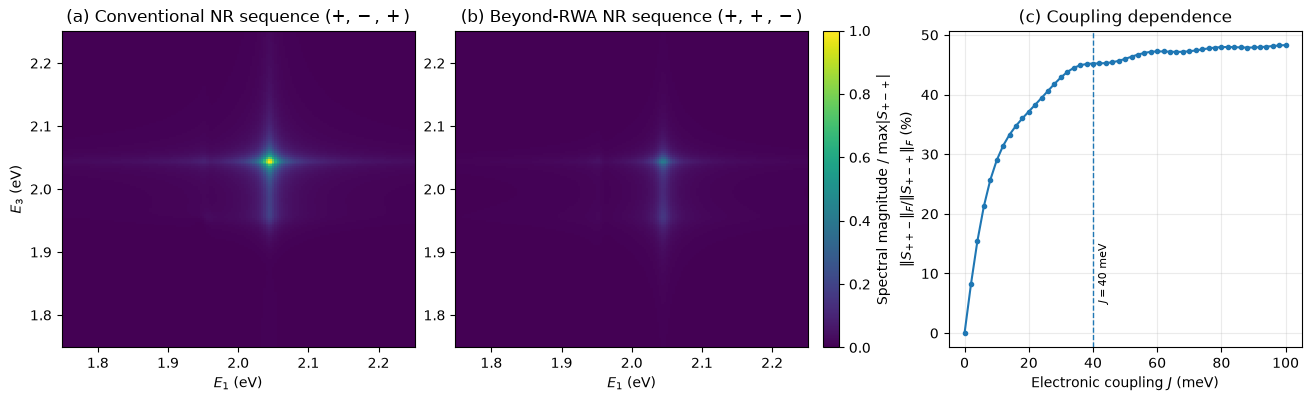

Saved:
../figures/07_physical_dimer_regimes/Figure06_NR_beyond_RWA_mechanism.pdf
../figures/07_physical_dimer_regimes/Figure06_NR_beyond_RWA_mechanism.png


In [88]:
# ------------------------------------------------------------
# Publication Figure 6:
# coupling-induced NR beyond-RWA channel
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 3.9),
    constrained_layout=True,
)

# Common scale:
# both spectra normalized to the RWA sequence maximum.
spectral_scale = np.max(
    np.abs(S_rwa_NR)
)

map_rwa = (
    np.abs(S_rwa_NR)
    / spectral_scale
)

map_cr = (
    np.abs(S_cr_NR)
    / spectral_scale
)

vmax_mech = max(
    1.0,
    np.max(map_cr),
)

pcm = axes[0].pcolormesh(
    E1_grid,
    E3_grid,
    map_rwa,
    shading="auto",
    vmin=0.0,
    vmax=vmax_mech,
)

axes[1].pcolormesh(
    E1_grid,
    E3_grid,
    map_cr,
    shading="auto",
    vmin=0.0,
    vmax=vmax_mech,
)

axes[0].set_title(
    r"(a) Conventional NR sequence $(+,-,+)$"
)

axes[1].set_title(
    r"(b) Beyond-RWA NR sequence $(+,+,-)$"
)

for ax in axes[:2]:

    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

axes[0].set_ylabel(
    r"$E_3$ (eV)"
)

# Coupling dependence
axes[2].plot(
    1000.0 * J_mech_scan,
    100.0 * ratio_mech_scan,
    marker="o",
    markersize=3,
)

axes[2].axvline(
    40.0,
    linestyle="--",
    linewidth=1.0,
)

axes[2].text(
    41.5,
    5.0,
    r"$J=40$ meV",
    rotation=90,
    va="bottom",
    fontsize=8,
)# ------------------------------------------------------------
# Long-pulse mechanism at J = 40 meV, FWHM = 20 fs
# ------------------------------------------------------------

J_long = 0.040
fwhm_long = 20.0
T_long = 100.0

sigma_long = (
    fwhm_long
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_long = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_long
    )
)

pulse_long = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_long,
    E0=E0_long,
)

system_long, _ = build_system_for_J(
    J_long
)

long_pulse_mechanism = {}

for pathway, omega1_i in [
    ("NR", omega1_grid),
    ("R", omega1_grid_R),
]:

    # Model B:
    # finite pulse + RWA + molecular evolution
    B_i = pulsus.finite_pulse_rwa_spectrum(
        system=system_long,
        pulse1=pulse_long,
        pulse2=pulse_long,
        pulse3=pulse_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    # Model C:
    # finite pulse + RWA, but no molecular evolution
    # during the pulse offsets
    C_i = pulsus.short_pulse_rwa_spectrum(
        system=system_long,
        pulse1=pulse_long,
        pulse2=pulse_long,
        pulse3=pulse_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    # Model D:
    # conventional impulsive RWA
    D_i = pulsus.impulsive_rwa_spectrum(
        system=system_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    err_BC_i = (
        np.linalg.norm(C_i - B_i)
        / np.linalg.norm(B_i)
    )

    err_CD_i = (
        np.linalg.norm(D_i - C_i)
        / np.linalg.norm(C_i)
    )

    long_pulse_mechanism[pathway] = {
        "B": B_i,
        "C": C_i,
        "D": D_i,
        "BC_error": err_BC_i,
        "CD_error": err_CD_i,
    }


print(
    "Long-pulse mechanism:"
)
print(
    "J = 40 meV, FWHM = 20 fs, T = 100 fs"
)
print(
    "--------------------------------------"
)

for pathway in ["NR", "R"]:

    data = long_pulse_mechanism[
        pathway
    ]

    print(
        f"{pathway}:  "
        f"B-C = {100*data['BC_error']:8.3f}%   "
        f"C-D = {100*data['CD_error']:8.3f}%"
    )

axes[2].set_xlabel(
    r"Electronic coupling $J$ (meV)"
)

axes[2].set_ylabel(
    r"$\|S_{++-}\|_F/\|S_{+-+}\|_F$ (%)"
)

axes[2].set_title(
    "(c) Coupling dependence"
)

axes[2].grid(
    alpha=0.25
)

cbar = fig.colorbar(
    pcm,
    ax=axes[:2],
    pad=0.02,
    fraction=0.04,
)

cbar.set_label(
    r"Spectral magnitude / "
    r"$\max|S_{+-+}|$"
)

pdf_file = (
    figdir
    / "Figure06_NR_beyond_RWA_mechanism.pdf"
)

png_file = (
    figdir
    / "Figure06_NR_beyond_RWA_mechanism.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

In [89]:
# ------------------------------------------------------------
# Long-pulse mechanism at J = 40 meV, FWHM = 20 fs
# ------------------------------------------------------------

J_long = 0.040
fwhm_long = 20.0
T_long = 100.0

sigma_long = (
    fwhm_long
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_long = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_long
    )
)

pulse_long = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma_long,
    E0=E0_long,
)

system_long, _ = build_system_for_J(
    J_long
)

long_pulse_mechanism = {}

for pathway, omega1_i in [
    ("NR", omega1_grid),
    ("R", omega1_grid_R),
]:

    # Model B:
    # finite pulse + RWA + molecular evolution
    B_i = pulsus.finite_pulse_rwa_spectrum(
        system=system_long,
        pulse1=pulse_long,
        pulse2=pulse_long,
        pulse3=pulse_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    # Model C:
    # finite pulse + RWA, but no molecular evolution
    # during the pulse offsets
    C_i = pulsus.short_pulse_rwa_spectrum(
        system=system_long,
        pulse1=pulse_long,
        pulse2=pulse_long,
        pulse3=pulse_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    # Model D:
    # conventional impulsive RWA
    D_i = pulsus.impulsive_rwa_spectrum(
        system=system_long,
        omega1=omega1_i,
        omega3=omega3_grid,
        T=T_long,
        eta=eta,
        pathway=pathway,
    )

    err_BC_i = (
        np.linalg.norm(C_i - B_i)
        / np.linalg.norm(B_i)
    )

    err_CD_i = (
        np.linalg.norm(D_i - C_i)
        / np.linalg.norm(C_i)
    )

    long_pulse_mechanism[pathway] = {
        "B": B_i,
        "C": C_i,
        "D": D_i,
        "BC_error": err_BC_i,
        "CD_error": err_CD_i,
    }


print(
    "Long-pulse mechanism:"
)
print(
    "J = 40 meV, FWHM = 20 fs, T = 100 fs"
)
print(
    "--------------------------------------"
)

for pathway in ["NR", "R"]:

    data = long_pulse_mechanism[
        pathway
    ]

    print(
        f"{pathway}:  "
        f"B-C = {100*data['BC_error']:8.3f}%   "
        f"C-D = {100*data['CD_error']:8.3f}%"
    )

Long-pulse mechanism:
J = 40 meV, FWHM = 20 fs, T = 100 fs
--------------------------------------
NR:  B-C =   31.724%   C-D =  164.739%
R:  B-C =   14.039%   C-D =  164.345%


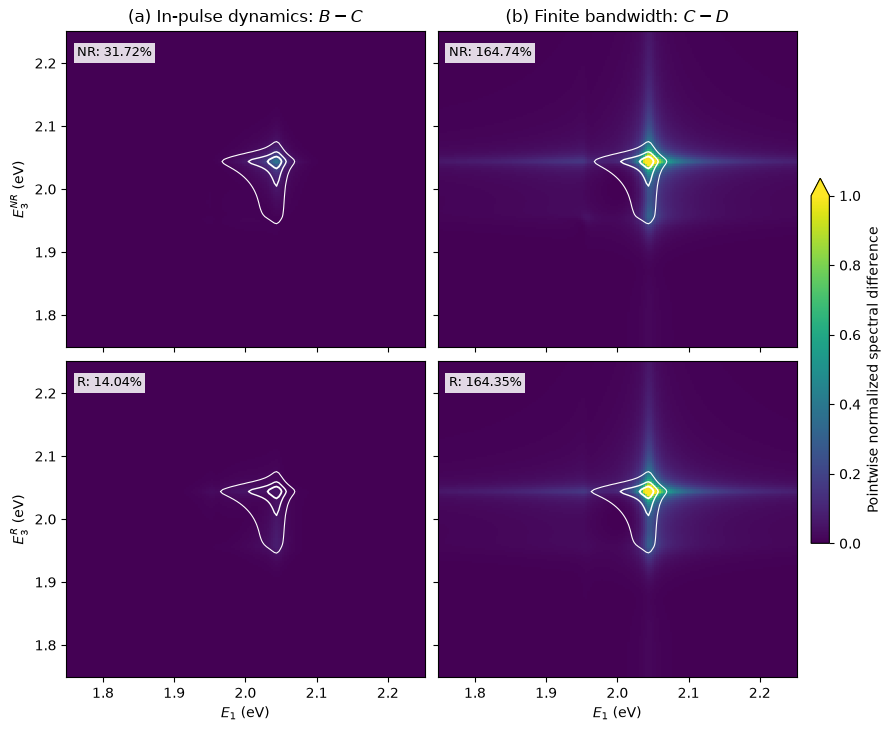

Saved:
../figures/07_physical_dimer_regimes/Figure07_long_pulse_mechanism.pdf
../figures/07_physical_dimer_regimes/Figure07_long_pulse_mechanism.png


In [90]:
# ------------------------------------------------------------
# Publication Figure 7:
# mechanisms of the long-pulse breakdown
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8.8, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

pcm = None

for row, pathway in enumerate(
    ["NR", "R"]
):

    data = long_pulse_mechanism[
        pathway
    ]

    B_i = data["B"]
    C_i = data["C"]
    D_i = data["D"]

    # --------------------------------------------------------
    # Left column: B -> C
    # loss of molecular evolution during the pulse
    # --------------------------------------------------------

    scale_B = np.max(
        np.abs(B_i)
    )

    error_BC = (
        np.abs(C_i - B_i)
        / scale_B
    )

    B_norm = (
        np.abs(B_i)
        / scale_B
    )

    ax = axes[row, 0]

    pcm = ax.pcolormesh(
        E1_grid,
        E3_grid,
        error_BC,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    ax.contour(
        E1_grid,
        E3_grid,
        B_norm,
        levels=[
            0.10,
            0.30,
            0.60,
        ],
        colors="white",
        linewidths=[
            0.8,
            1.0,
            1.3,
        ],
    )

    ax.text(
        0.03,
        0.95,
        (
            f"{pathway}: "
            f"{100*data['BC_error']:.2f}%"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="none",
            pad=2.5,
        ),
    )

    # --------------------------------------------------------
    # Right column: C -> D
    # loss of finite spectral bandwidth
    # --------------------------------------------------------

    scale_C = np.max(
        np.abs(C_i)
    )

    error_CD = (
        np.abs(D_i - C_i)
        / scale_C
    )

    C_norm = (
        np.abs(C_i)
        / scale_C
    )

    ax = axes[row, 1]

    pcm = ax.pcolormesh(
        E1_grid,
        E3_grid,
        error_CD,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    ax.contour(
        E1_grid,
        E3_grid,
        C_norm,
        levels=[
            0.10,
            0.30,
            0.60,
        ],
        colors="white",
        linewidths=[
            0.8,
            1.0,
            1.3,
        ],
    )

    ax.text(
        0.03,
        0.95,
        (
            f"{pathway}: "
            f"{100*data['CD_error']:.2f}%"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="none",
            pad=2.5,
        ),
    )


axes[0, 0].set_title(
    r"(a) In-pulse dynamics: $B-C$"
)

axes[0, 1].set_title(
    r"(b) Finite bandwidth: $C-D$"
)

for ax in axes[1, :]:
    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

axes[0, 0].set_ylabel(
    r"$E_3^{NR}$ (eV)"
)

axes[1, 0].set_ylabel(
    r"$E_3^{R}$ (eV)"
)

cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.025,
    extend="max",
)

cbar.set_label(
    "Pointwise normalized spectral difference"
)

pdf_file = (
    figdir
    / "Figure07_long_pulse_mechanism.pdf"
)

png_file = (
    figdir
    / "Figure07_long_pulse_mechanism.png"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file)
print(png_file)

### Origin of the long-pulse breakdown

The long-pulse side of the impulsive-RWA validity regime contains two
distinct finite-pulse effects.

At \(J=40\) meV, \(T=100\) fs, and an intensity FWHM of \(20\) fs,
neglecting molecular evolution during the pulse produces

\[
\epsilon_{BC}^{NR}=31.7\%,
\qquad
\epsilon_{BC}^{R}=14.0\%.
\]

Thus the short-pulse approximation already fails substantially, with a
stronger effect in the nonrephasing branch.

The subsequent replacement of the finite pulse envelope by the
impulsive limit produces a still larger error,

\[
\epsilon_{CD}^{NR}=164.7\%,
\qquad
\epsilon_{CD}^{R}=164.3\%.
\]

For this representative long-pulse case, the total breakdown therefore
arises from both molecular evolution during the pulse and finite
spectral-bandwidth filtering, with the latter providing the dominant
contribution.

Together with the ultrashort-pulse molecular-sequence analysis, these
results explain both boundaries of the finite intermediate regime in
which the conventional impulsive-RWA description remains quantitatively
accurate.

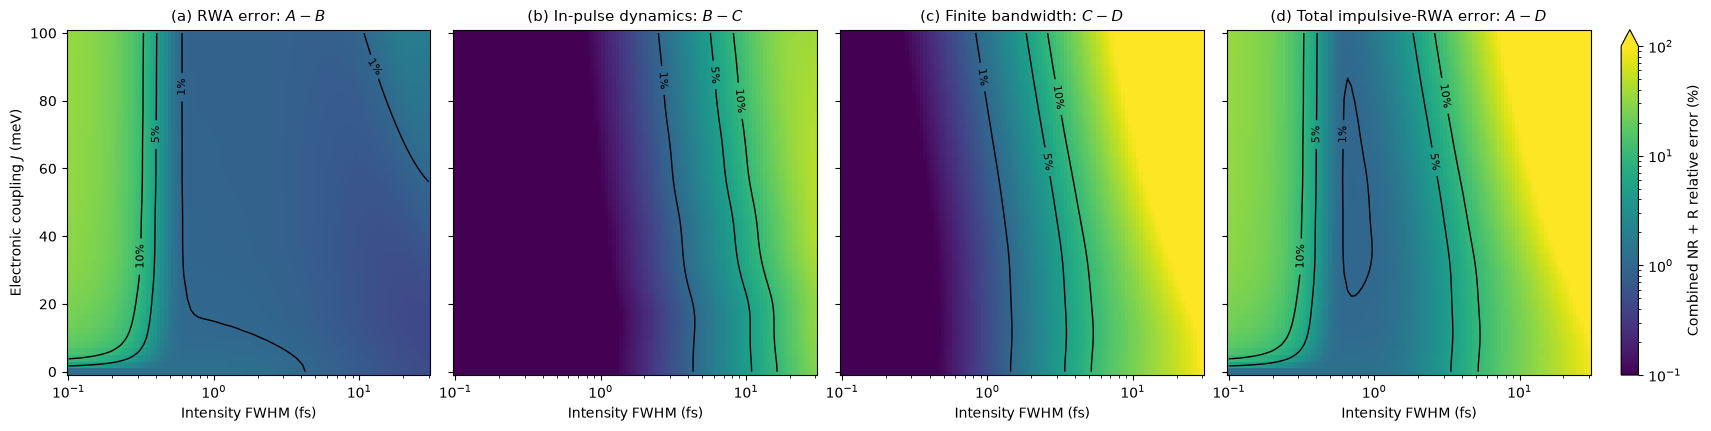

Saved:
../figures/07_physical_dimer_regimes/Figure04_full_hierarchy_regime_map.pdf
../figures/07_physical_dimer_regimes/Figure04_full_hierarchy_regime_map.png


In [91]:
# ------------------------------------------------------------
# Alternative publication Figure 4:
# complete A -> B -> C -> D approximation hierarchy
# ------------------------------------------------------------

from matplotlib.colors import LogNorm

maps_hierarchy = [
    100.0 * AB_dense,
    100.0 * BC_dense,
    100.0 * CD_dense,
    100.0 * AD_dense,
]

titles_hierarchy = [
    r"(a) RWA error: $A-B$",
    r"(b) In-pulse dynamics: $B-C$",
    r"(c) Finite bandwidth: $C-D$",
    r"(d) Total impulsive-RWA error: $A-D$",
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(17.0, 4.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = LogNorm(
    vmin=0.1,
    vmax=100.0,
)

for ax, data, title in zip(
    axes,
    maps_hierarchy,
    titles_hierarchy,
):

    pcm = ax.pcolormesh(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        shading="auto",
        norm=norm,
    )

    cs = ax.contour(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        levels=[
            1.0,
            5.0,
            10.0,
        ],
        colors="black",
        linewidths=1.0,
    )

    ax.clabel(
        cs,
        fmt=lambda x: f"{x:.0f}%",
        fontsize=8,
    )

    ax.set_xscale("log")

    ax.set_xlabel(
        "Intensity FWHM (fs)"
    )

    ax.set_title(
        title,
        fontsize=11,
    )

axes[0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.02,
    extend="max",
)

cbar.set_label(
    "Combined NR + R relative error (%)"
)

pdf_file_full = (
    figdir
    / "Figure04_full_hierarchy_regime_map.pdf"
)

png_file_full = (
    figdir
    / "Figure04_full_hierarchy_regime_map.png"
)

fig.savefig(
    pdf_file_full,
    bbox_inches="tight",
)

fig.savefig(
    png_file_full,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file_full)
print(png_file_full)

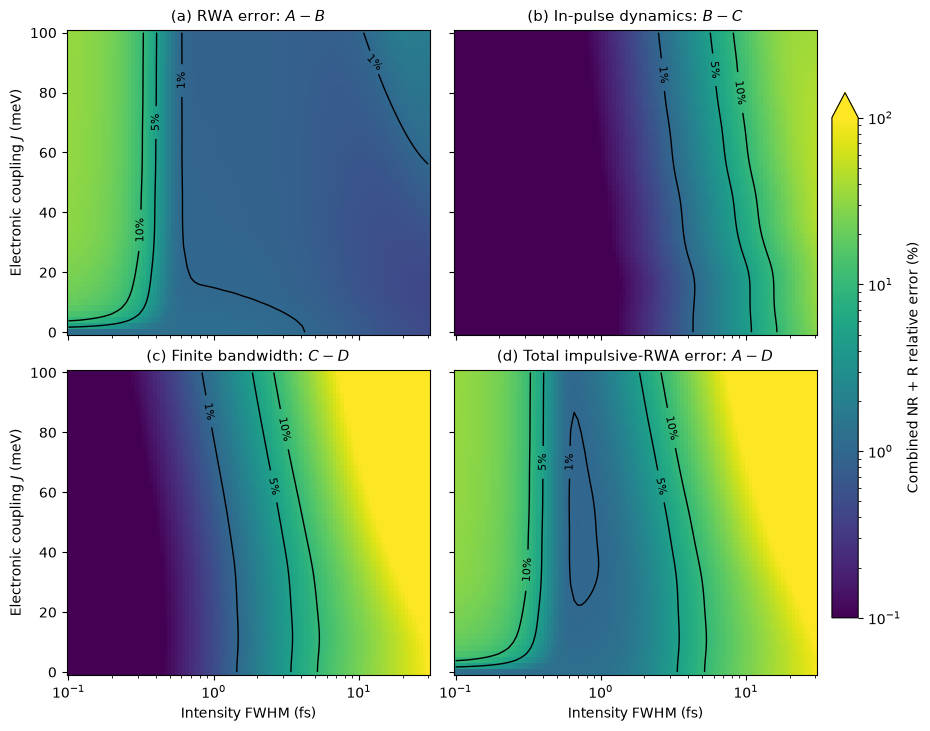

Saved:
../figures/07_physical_dimer_regimes/Figure04_full_hierarchy_regime_map_2x2.pdf
../figures/07_physical_dimer_regimes/Figure04_full_hierarchy_regime_map_2x2.png


In [92]:
# ------------------------------------------------------------
# Alternative publication Figure 4:
# complete hierarchy in compact 2 x 2 layout
# ------------------------------------------------------------

from matplotlib.colors import LogNorm

maps_hierarchy_2x2 = [
    100.0 * AB_dense,
    100.0 * BC_dense,
    100.0 * CD_dense,
    100.0 * AD_dense,
]

titles_hierarchy_2x2 = [
    r"(a) RWA error: $A-B$",
    r"(b) In-pulse dynamics: $B-C$",
    r"(c) Finite bandwidth: $C-D$",
    r"(d) Total impulsive-RWA error: $A-D$",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9.2, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

norm = LogNorm(
    vmin=0.1,
    vmax=100.0,
)

axes_flat = axes.ravel()

for ax, data, title in zip(
    axes_flat,
    maps_hierarchy_2x2,
    titles_hierarchy_2x2,
):

    pcm = ax.pcolormesh(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        shading="auto",
        norm=norm,
    )

    cs = ax.contour(
        fwhm_mesh_dense,
        J_mesh_dense,
        data,
        levels=[
            1.0,
            5.0,
            10.0,
        ],
        colors="black",
        linewidths=1.0,
    )

    ax.clabel(
        cs,
        fmt=lambda x: f"{x:.0f}%",
        fontsize=8,
    )

    ax.set_xscale("log")

    ax.set_title(
        title,
        fontsize=11,
    )


# x-axis labels only on bottom row
axes[1, 0].set_xlabel(
    "Intensity FWHM (fs)"
)

axes[1, 1].set_xlabel(
    "Intensity FWHM (fs)"
)

# y-axis labels only on left column
axes[0, 0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)

axes[1, 0].set_ylabel(
    r"Electronic coupling $J$ (meV)"
)


cbar = fig.colorbar(
    pcm,
    ax=axes,
    pad=0.02,
    fraction=0.035,
    extend="max",
)

cbar.set_label(
    "Combined NR + R relative error (%)"
)


pdf_file_2x2 = (
    figdir
    / "Figure04_full_hierarchy_regime_map_2x2.pdf"
)

png_file_2x2 = (
    figdir
    / "Figure04_full_hierarchy_regime_map_2x2.png"
)

fig.savefig(
    pdf_file_2x2,
    bbox_inches="tight",
)

fig.savefig(
    png_file_2x2,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(pdf_file_2x2)
print(png_file_2x2)